# Network and rheological properties of nanomotif assemblies simulated with ReaDDy CG model

Rheological data extracted with graph-based method developed in Alshareedah et al. Sequence-specific interactions determine viscoelasticity and ageing dynamics of protein condensates, 2024 and Cohen et al. Direct computations of viscoelastic moduli of biomolecular condensates, 2024

In [1]:
%load_ext autoreload
%autoreload 2

# Import

In [2]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import readdy
import math
import scipy
import pandas as pd
import sklearn
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler
import contextlib
import io
import pickle
import torch
from botorch.models import SingleTaskGP
from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.likelihoods import FixedNoiseGaussianLikelihood
from botorch.acquisition import LogExpectedImprovement
from botorch.acquisition import ExpectedImprovement
from botorch.acquisition import UpperConfidenceBound
from botorch.optim import optimize_acqf
import multiprocessing

from scipy.optimize import curve_fit
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_percentage_error,mean_squared_log_error,mean_absolute_error
import threading
from concurrent.futures import ThreadPoolExecutor
from scipy.interpolate import interp1d

import sys
import os
import seaborn as sns
#sys.path.append(os.path.abspath(os.path.join('..', 'python_scripts')))

from NCG_readdy_sim_4 import Debye_length, Debye_Hueckel_pot_rep_strength ,Diff_at23C,visc_T,Diff_ES

from NCG_readdy_sim_4 import run_sim_3,tcl_file_gen_3,all_types

from NCG_Bay_opt_readdy_sim_3 import run_p,run_p_dict,gt_1_3,gt_1_1,gt_1_2,gt_1_4, cg_angle_distr_c1_4_ba_aa_oa_la,cg_angle_distr_c1_1_hp,cg_angle_distr_c1_1_bm, eval_sim_c1_1_la,eval_sim_c1_1_hp,eval_sim_c1_1_aa,eval_sim_c1_2_ba_oa, eval_sim_c1_4_ba_aa_oa_la,eval_sim_c1_1_bm,apply_gp, run_gp_11

from NCG_Bay_opt_readdy_sim_3 import gen_all_comb_from_list_of_lists_2

#from NCG_readdy_sim_eval_1 import get_particle_number_from_sims
#from NCG_readdy_sim_eval_3 import get_particle_number_from_sims2,avg_largest_component_size,find_intersection,shift_graphs,get_time_avg_storage_loss_mod_2, get_subgraph_eigenvalues, relax_times, storage_mod, loss_mod_deref,relaxation_mod,get_time_avg_storage_loss_mod_4,get_subgraph_eigenvalues,get_time_avg_storage_loss_mod

from NCG_readdy_sim_eval_3 import *
from NCG_theo_graphs_1 import *

# Load in example simulations

In [3]:

#load saved config
traj_mech=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_checkpoint_0/x_c_mech_opt_prod_0.h5")

times_mech,types_mech,ids_mech,part_positions_mech=traj_mech.read_observable_particles()
time_pt_mech, counts_pt_mech = traj_mech.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech, energy_mech=traj_mech.read_observable_energy()

time_obs_top_mech,obs_top_mech=traj_mech.read_observable_topologies()

####################
####################
####################


#load saved config
traj_mech2=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_0/x_c_mech_opt_prod_cont_2_0.h5")

times_mech2,types_mech2,ids_mech2,part_positions_mech2=traj_mech2.read_observable_particles()
time_pt_mech2, counts_pt_mech2 = traj_mech2.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech2, energy_mech2=traj_mech2.read_observable_energy()

time_obs_top_mech2,obs_top_mech2=traj_mech2.read_observable_topologies()


####################
####################
####################


#load saved config
traj_mech3=readdy.Trajectory("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/prod_checkpoint_0/x_c_mech_opt_prod_0.h5")

times_mech3,types_mech3,ids_mech3,part_positions_mech3=traj_mech3.read_observable_particles()
time_pt_mech3, counts_pt_mech3 = traj_mech3.read_observable_number_of_particles()
#part_pos_eq=part_positions

time_e_mech3, energy_mech3=traj_mech3.read_observable_energy()

time_obs_top_mech3,obs_top_mech3=traj_mech3.read_observable_topologies()

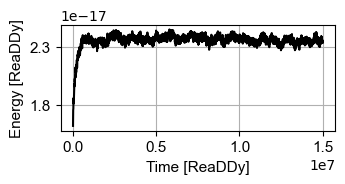

In [11]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

plt.errorbar(time_e_mech3, energy_mech3,color="black")


plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks([1.8*10**-17,2.3*10**-17],fontname = "Arial",fontsize=11)
plt.ylabel("Energy [ReaDDy]",fontname = "Arial",fontsize=11)
plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=11)
plt.grid()

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/example_energy_100motifs_readdy_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [ ]:
#generate xyz file for visualisation
radii={}
for i in range(len(all_types)):
    radii[all_types[i]]=1.36

#traj_mech3.convert_to_xyz(particle_radii=radii)

In [ ]:
#save tcl file for visualisation
tcl_file_mech=tcl_file_gen_3(traj_file="x_c_mech_opt_prod_0.h5.xyz",box_dim_s="69.718 69.718 69.718")

#np.savetxt("/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_0/tcl_x_c_mech_opt_prod_0.h5.tcl",tcl_file_mech,delimiter=" ", fmt="%s")

# Fraction of bound sticky ends 

In [4]:
# define which simulations to use 

# optimised, r_ub=0.05
#folder_name_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_8/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.02
folder_name_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_9/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.005
folder_name_ex2=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.0005
folder_name_ex3=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_4/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.0001
folder_name_ex4=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_6/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.00005
folder_name_ex5=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_7/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0.000005
folder_name_ex6=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_5/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0 (part 1)
folder_name_ex7=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0 (part 2)
folder_name_ex8=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_"+str(e)+".h5" for e in [0,1,2,3,4]]

# optimised, r_ub=0 (part 3)
folder_name_ex9=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]


#############
#############

#gather all simulation names in one list
folder_names_all_ex=[folder_name_ex1,folder_name_ex2,folder_name_ex3,folder_name_ex4,folder_name_ex5,folder_name_ex6,folder_name_ex7,folder_name_ex8,folder_name_ex9]

In [5]:
%%time

#use parallel execution to calculate the fraction of bound sticky ends in all simulations

# List of input parameter tuples (names, [IDs of sticky end particles in ReaDDy])
inputs_part_num = [(folder_name_ex1, [31,33,35,37]), (folder_name_ex2, [31,33,35,37]), (folder_name_ex3, [31,33,35,37]), (folder_name_ex4, [31,33,35,37]), (folder_name_ex5, [31,33,35,37]),(folder_name_ex6, [31,33,35,37]),(folder_name_ex7, [31,33,35,37]),(folder_name_ex8, [31,33,35,37]),(folder_name_ex9, [31,33,35,37])]

# Run in parallel

with ThreadPoolExecutor(max_workers=12) as executor:
    results_part_num = list(executor.map(lambda args: get_particle_number_from_sims2(*args), inputs_part_num))



CPU times: user 19.7 s, sys: 15.8 s, total: 35.5 s
Wall time: 4min 55s


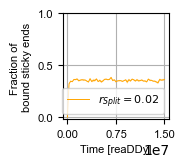

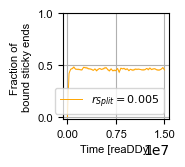

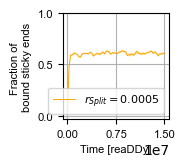

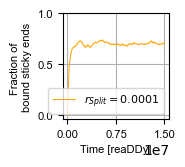

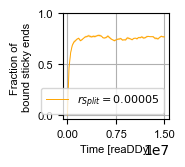

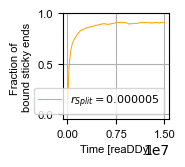

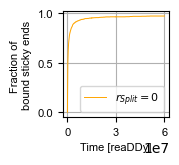

In [6]:
# plot fraction of bound sticky ends as function of time

#all simulations:
fused_linkers_ex_all=[results_part_num[e] for e in [0,1,2,3,4,5,6,7,8] ] #[fused_linkers_ex1,fused_linkers_ex2,fused_linkers_ex3,fused_linkers_ex4,fused_linkers_ex4]

rates_ub_ex_all=[r"$r_{Split}=0.02$",r"$r_{Split}=0.005$",r"$r_{Split}=0.0005$",r"$r_{Split}=0.0001$",r"$r_{Split}=0.00005$",r"$r_{Split}=0.000005$",r"$r_{Split}=0$"]


for i in range(len(fused_linkers_ex_all[:-2])):  
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    #fig=plt.figure(figsize=(5,5))

    #simulations done in one run
    mean_fused_linkers=np.mean(fused_linkers_ex_all[i],axis=0)/400
    std_e_fused_linkers=np.std(fused_linkers_ex_all[i],axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
    
    plt.errorbar(time_pt_mech[::50],mean_fused_linkers[::50],label=rates_ub_ex_all[i],color="orange",linewidth=0.7)
    plt.fill_between(time_pt_mech[::50], mean_fused_linkers[::50] + std_e_fused_linkers[::50], mean_fused_linkers[::50] - std_e_fused_linkers[::50], alpha = 0.3 ,facecolor="orange")
    
     #piece together results from split simulation
    if i==6:
        #fused_linkers_ex1_cont=results_part_num[-3]
        #mean_fused_linkers_cont=np.mean(fused_linkers_ex1_cont,axis=0)/400
        #std_e_fused_linkers_cont=np.std(fused_linkers_ex1_cont,axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
        #plt.errorbar(time_pt_mech[::50],mean_fused_linkers_cont[::50],color="orange",linewidth=0.7)
        #plt.fill_between(time_pt_mech[::50], mean_fused_linkers_cont[::50] + std_e_fused_linkers_cont[::50], mean_fused_linkers_cont[::50] - std_e_fused_linkers_cont[::50], alpha = 0.3 ,facecolor="orange")

        #1st cont. of sim
        fused_linkers_ex1_cont=results_part_num[-2]
        mean_fused_linkers_cont=np.mean(fused_linkers_ex1_cont,axis=0)/400
        std_e_fused_linkers_cont=np.std(fused_linkers_ex1_cont,axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
        plt.errorbar(time_pt_mech[::50]+time_pt_mech[-1],mean_fused_linkers_cont[::50],color="orange",linewidth=0.7)
        plt.fill_between(time_pt_mech[::50]+time_pt_mech[-1], mean_fused_linkers_cont[::50] + std_e_fused_linkers_cont[::50], mean_fused_linkers_cont[::50] - std_e_fused_linkers_cont[::50], alpha = 0.3 ,facecolor="orange")

        #2nd cont. of sim
        fused_linkers_ex1_cont2=results_part_num[-1]
        mean_fused_linkers_cont2=np.mean(fused_linkers_ex1_cont2,axis=0)/400
        std_e_fused_linkers_cont2=np.std(fused_linkers_ex1_cont2,axis=0)/(np.sqrt(fused_linkers_ex_all[i].shape[0])*400)
        plt.errorbar(time_pt_mech2[::50]+time_pt_mech[-1]*2,mean_fused_linkers_cont2[::50],color="orange",linewidth=0.7)
        plt.fill_between(time_pt_mech2[::50]+time_pt_mech[-1]*2, mean_fused_linkers_cont2[::50] + std_e_fused_linkers_cont2[::50], mean_fused_linkers_cont2[::50] - std_e_fused_linkers_cont2[::50], alpha = 0.3 ,facecolor="orange")
  
        
        fs1=8
        plt.xticks([0,3*10**7,6*10**7],fontname = "Arial",fontsize=fs1)
        plt.yticks([0,0.5,1],fontname = "Arial",fontsize=fs1)
    
    else:
        fs1=8
        plt.xticks([0,0.75*10**7,1.5*10**7],fontname = "Arial",fontsize=fs1)
        plt.yticks([0,0.5,1],fontname = "Arial",fontsize=fs1)
    plt.ylabel("Fraction of \nbound sticky ends",fontname = "Arial",fontsize=fs1)
    plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=fs1)
    plt.grid()
    plt.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i==0:
        #
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/fraction_bound_sticky_ends_"+str(i)+"_1.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
    #plt.show()

In [7]:
#print mean and std of bound fraction

print("Mean fraction of fused SE:",np.mean(np.mean(fused_linkers_ex_all[0],axis=0)[2250:],axis=0)/400 *100)
print("Stde of fraction of fused SE:",np.std(np.mean(fused_linkers_ex_all[0],axis=0)[2250:],axis=0)/(400*np.sqrt(5))*100)


print("Mean fraction of fused SE:",np.mean(np.mean(fused_linkers_ex_all[8],axis=0)[5250:],axis=0)/400)
print("Stde of fraction of fused SE:",np.std(np.mean(fused_linkers_ex_all[8],axis=0)[5250:],axis=0)/(400*np.sqrt(5)))


Mean fraction of fused SE: 35.16191744340879
Stde of fraction of fused SE: 0.399083783867919
Mean fraction of fused SE: 0.97
Stde of fraction of fused SE: 0.0


# Plot components (connected sub-graphs of nanomotifs)

In [41]:
#get particles per component (component size) from the three sims read in before
#divide size by 13 because every nanomotif has 13 particles
particles_per_component_read_in=[]
for i in range(len(obs_top_mech)):
    comp_lens=[]
    for j in range(len(obs_top_mech[i])):
        comp_lens.append(len(obs_top_mech[i][j].particles)/13)
    particles_per_component_read_in.append(comp_lens)


particles_per_component_read_in2=[]
for i in range(len(obs_top_mech2)):
    comp_lens2=[]
    for j in range(len(obs_top_mech2[i])):
        comp_lens2.append(len(obs_top_mech2[i][j].particles)/13)
    particles_per_component_read_in2.append(comp_lens2)

particles_per_component_read_in3=[]
for i in range(len(obs_top_mech3)):
    comp_lens3=[]
    for j in range(len(obs_top_mech3[i])):
        comp_lens3.append(len(obs_top_mech3[i][j].particles)/13)
    particles_per_component_read_in3.append(comp_lens3)

In [5]:
#get average largest component size

comp_size_folder_name_ex1_cont2=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]

print(avg_largest_component_size(traj_names=comp_size_folder_name_ex1_cont2,t_skip=5250))

(98.8, 0.17888543819998318)


In [72]:
#get averate largest component size

comp_size_folder_name_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_9/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

print(avg_largest_component_size(traj_names=comp_size_folder_name_ex1,t_skip=2250))

(27.361118508655125, 0.531923828495203)


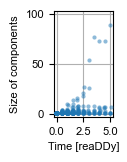

In [43]:
#plot time evolution of components in one exp sim 
start=0#70000       #39100
stop=101 #1001       #40100
step=10           #100
stp_x_l=np.arange(start,stop,step)*5*10**3

##step=25, stop=101, step_x=2
alpha_1=0.5

fig=plt.figure(figsize=(3.5/2.54 *0.55,3.5/2.54))

# stripplot of ortho x
stp_y=particles_per_component_read_in3[start:stop:step]
stp_x=np.arange(0,len(stp_y))
start_x=0
stop_x=len(stp_x)
step_x=5


fs1=8
sns.stripplot(data=stp_y,alpha=alpha_1,size=3,color="tab:blue")
plt.xticks(stp_x[start_x:stop_x:step_x],[0.0,2.5,5.0],fontname = "Arial",fontsize=fs1)

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([0,50,100],[0,50,100],fontname = "Arial",fontsize=fs1)

plt.ylabel("Size of components",fontname = "Arial",fontsize=fs1)
plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=fs1)
plt.ylim(-3,103)
plt.grid()
#plt.legend(prop={'family': 'Arial','size': 11},loc="upper right")

#plt.show()

#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V2a.pdf"
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V3a.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")



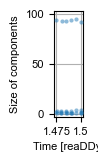

In [44]:
#plot final section of time evolution od components
start=len(time_pt_mech3)-51#70000       #39100
stop=len(time_pt_mech3) #101 #1001       #40100
step=10           #100
stp_x_l=np.arange(start,stop,step)*5*10**3

##step=25, stop=101, step_x=2
alpha_1=0.5

fig=plt.figure(figsize=(3.5/(2.54*2)*0.55,3.5/2.54))

# stripplot of ortho x
#stp_y=particles_per_component_read_in[start:stop:step]
stp_y=particles_per_component_read_in3[start:stop:step]

stp_x=np.arange(0,len(stp_y))
start_x=0
stop_x=len(stp_x)
step_x=5


fs1=8
sns.stripplot(data=stp_y,alpha=alpha_1,size=3,color="tab:blue")
plt.xticks(stp_x[start_x:stop_x:step_x],[1.475,1.5],fontname = "Arial",fontsize=fs1)

plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([0,50,100],[0,50,100],fontname = "Arial",fontsize=fs1)

plt.ylabel("Size of components",fontname = "Arial",fontsize=fs1)
plt.xlabel("Time [ReaDDy]",fontname = "Arial",fontsize=fs1)
plt.ylim(-3,103)
#plt.xscale("log")
plt.grid()
#plt.legend(prop={'family': 'Arial','size': 11},loc="upper right")

#plt.show()

#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V2b.pdf"
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/size_of_comp_D_shear_mod_soft_2_x_c_mech_opt_prod_0_V3b.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")



# Connectivity and largest component as function of sticky end affinites

Fitted parameters: a=1483.4054528372078,n=-4.553678459097675e-05, b=-1483.6296624963638
R-squared: 0.998480773298693
RMSE: 0.008253041367818983
prediction: 0.351234190863579


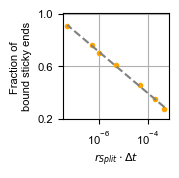

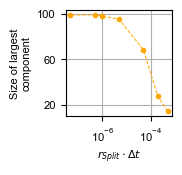

In [73]:
r_sp_list=np.array([5*10**-4,2*10**-4,5*10**-5,5*10**-6,1*10**-6,5*10**-7,5*10**-8,0])

bound_se_list=np.array([27.7,35.2,45.6,60.9,70.2,76.2,90.53,97])/100
bound_se_err_list=np.array([0.4,0.4,0.4,0.5,0.5,0.3,0.13,0])/100

largest_comp_list=np.array([14.59,27.4,68.4,94.93,97.78,98.71,98.80,98.80])
largest_comp_err_list=np.array([0.10,0.5,1.1,0.24,0.14,0.14,0.18,0.18])


fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

#fig=plt.figure(figsize=(5,5))

ax1.errorbar(r_sp_list,bound_se_list,yerr=bound_se_err_list,color="orange",linewidth=0.7,fmt=".")
#ax1.errorbar(r_sp_list,bound_se_list,yerr=bound_se_err_list,color="orange",linewidth=0.7,fmt="--")




def model_s(x, a,n, b):
    return a*x**n +b
x1=r_sp_list[:-1]
y1=bound_se_list[:-1]
params, _ = curve_fit(model_s, x1,y1,p0=[1,-0.5,75],maxfev = 20000)

# Extract fitted parameters
a,n, b = params
print(f"Fitted parameters: a={a},n={n}, b={b}")

x1_range=np.linspace(x1[0],x1[-1],1000)

ax1.errorbar(x1_range,model_s(x1_range,*params),color="grey",fmt="--")

#plt.errorbar(rd_elem,19000*rd_elem**-0.66

plt.xscale("log")
#plt.yscale("log")

#ax1.set_yscale('symlog')
#ax1.set_xscale('symlog')
fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([0.2,0.6,1],fontname = "Arial",fontsize=fs1)
plt.ylabel("Fraction of \nbound sticky ends",fontname = "Arial",fontsize=fs1)
plt.xlabel(r"$r_{Split}\cdot\Delta t$",fontname = "Arial",fontsize=fs1)
plt.grid()


# Predict y values using the fitted model
y_pred = model_s(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")
print("prediction:",model_s(2*10**-4, *params))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/frac_bound_fct_split_rate_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")



fig2=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax2 = fig2.add_subplot(111)

#fig=plt.figure(figsize=(5,5))

ax2.errorbar(r_sp_list,largest_comp_list,yerr=largest_comp_err_list,color="orange",linewidth=0.7,fmt=".")
ax2.errorbar(r_sp_list,largest_comp_list,yerr=largest_comp_err_list,color="orange",linewidth=0.7,fmt="--")

plt.xscale("log")
#plt.yscale("log")

#ax1.set_yscale('symlog')
#ax1.set_xscale('symlog')
fs1=8
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks([20,60,100],fontname = "Arial",fontsize=fs1)
plt.ylabel("Size of largest\ncomponent",fontname = "Arial",fontsize=fs1)
plt.xlabel(r"$r_{Split}\cdot\Delta t$",fontname = "Arial",fontsize=fs1)
plt.grid()
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/largest_comp_fct_split_rate_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


# Storage and loss modulus from simulations

In [5]:
%%time 

#calculate G' and G'' from simulations

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)

#use skip 5250 for cont 2 read in , use skip 11250 for 6e7 run (soft with r_ub=0)
folder_names_dyn_mod=[folder_names_all_ex[e] for e in [0,1,2,3,4,5,8]]
time_skip_dyn_mod=[2250,2250,2250,2250,2250,2250,5250]
#print(folder_names_dyn_mod)
input_dyn_mod=[]
for i in range(len(folder_names_dyn_mod)):
    input_dyn_mod.append((folder_names_dyn_mod[i],omega_t_sim1,t_sim1,1,1,1,1,1,15,time_skip_dyn_mod[i]))


with ThreadPoolExecutor(max_workers=18) as executor:
    results_dyn_mod = list(executor.map(lambda args: avg_moduli_3(*args), input_dyn_mod))



/home/aaron/phd/Nanomotif_Coarse_Graining_1/NCG_readdy_sim_eval_3.py:491: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  eigv_all_t=np.array(eigv_all_t)
/home/aaron/phd/Nanomotif_Coarse_Graining_1/NCG_readdy_sim_eval_3.py:492: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  tau_all_t=np.array(tau_all_t)


CPU times: user 16min 36s, sys: 29min 30s, total: 46min 6s
Wall time: 5min 24s


In [6]:
# split results in storage, loss and cross links
storage_mod_all_sims_all=[results_dyn_mod[e][0] for e in range(len(results_dyn_mod))]
loss_mod_all_sims_all=[results_dyn_mod[e][1] for e in range(len(results_dyn_mod))]
cross_links_all_sims_all=[results_dyn_mod[e][2] for e in range(len(results_dyn_mod))]

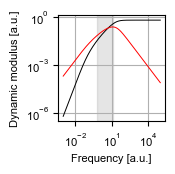

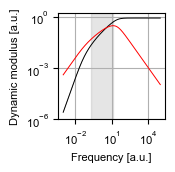

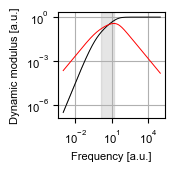

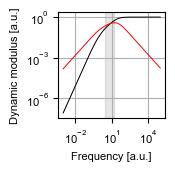

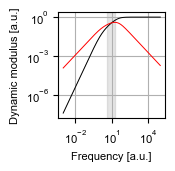

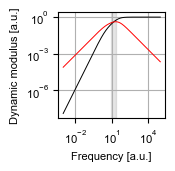

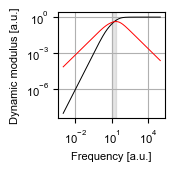

In [59]:
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_all_sims_all)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    
    ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")

    #determine scaling
    n1=np.gradient(mean_storage_mod_all_sims_ex1,omega_t_sim1)/mean_storage_mod_all_sims_ex1 *omega_t_sim1
    n2=np.gradient(mean_loss_mod_all_sims_ex1,omega_t_sim1)/mean_loss_mod_all_sims_ex1 *omega_t_sim1
    # Condition: 0 < n < 1 for both
    mask = (n1 > 0) & (n1 < 1) & (n2 > 0) & (n2 < 1)
    
    # Find indices where condition holds
    indices = np.where(mask)[0]
    
    start_idx = indices[0]
    end_idx = indices[-1] 

    ax1.axvspan(omega_t_sim1[start_idx], omega_t_sim1[end_idx], color='gray', alpha=0.2)


    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    #plt.ylim(10**-6,2)
    #plt.xlim(10**-3,10**3)
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    #plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
    #plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    #ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
    #if i ==0:
    save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_ub_rate_"+str(i)+"_1b.pdf"
    #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

1000 1000
1000 1000
1000 1000
1000 1000
1000 1000
1000 1000
1000 1000


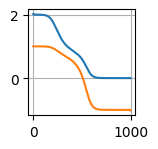

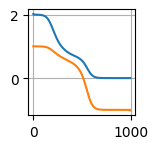

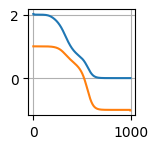

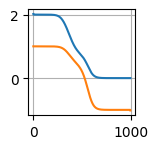

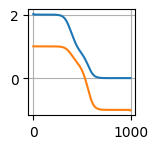

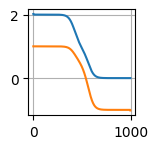

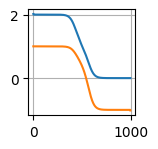

In [52]:
#slopes of G' and G''
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
for i in range(len(storage_mod_all_sims_all)):
    fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig.add_subplot(111)
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    
    #ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt="-",label=r"$G'$",color="black",linewidth=0.7)
    #ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    #ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=0.7)
    #ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")


        
    
    
 
    # Compute log differences
    log_x = np.log(np.arange(1, len(mean_storage_mod_all_sims_ex1)+1))  # assuming index as x
    log_y1 = np.log(mean_storage_mod_all_sims_ex1)
    log_y2 = np.log(mean_loss_mod_all_sims_ex1)
    
    # Approximate local scaling exponent n
    #n1 = np.diff(log_y1) / np.diff(log_x)
    #n2 = np.diff(log_y2) / np.diff(log_x)
    n1=np.gradient(mean_storage_mod_all_sims_ex1,omega_t_sim1)/mean_storage_mod_all_sims_ex1 *omega_t_sim1
    n2=np.gradient(mean_loss_mod_all_sims_ex1,omega_t_sim1)/mean_loss_mod_all_sims_ex1 *omega_t_sim1
    print(len(n1),len(mean_storage_mod_all_sims_ex1))
    #mean_slope_storage_mod=np.gradient(np.mean(mean_storage_mod_all_sims_ex1,axis=0),omega_t_sim1) /np.mean(mean_storage_mod_all_sims_ex1,axis=0) *omega_t_sim1
    #mean_slope_loss_mod=np.gradient(np.mean(mean_loss_mod_all_sims_ex1,axis=0),omega_t_sim1)/np.mean(mean_loss_mod_all_sims_ex1,axis=0) *omega_t_sim1
    plt.plot(n1)
    plt.plot(n2)
    # Condition: 0 < n < 1 for both
    mask = (n1 > 0) & (n1 < 1) & (n2 > 0) & (n2 < 1)

    
    # Find indices where condition holds
    indices = np.where(mask)[0]
    
    start_idx = indices[0]
    end_idx = indices[-1] + 1  # +1 because diff reduces length by 1
    #ax1.axvline(log_x[end_idx])
    #ax1.axvline(log_x[start_idx])
   # ax1.axvspan(start_idx, end_idx, color='gray', alpha=0.3)

    
    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    fs1=8
    #plt.xscale("log")
    #plt.yscale("log")
    plt.grid()



<Figure size 1000x1000 with 0 Axes>

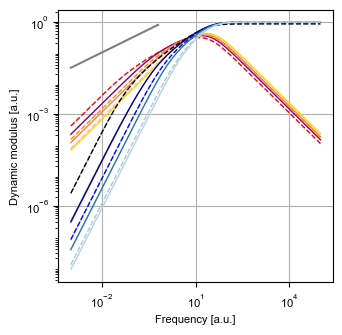

In [66]:
fig=plt.figure(figsize=(10,10))
fig=plt.figure(figsize=(9/2.54,9/2.54))

ax1 = fig.add_subplot(111)
"""
1: ub rate 0.005
2: ub rate 0.0005
7: ub rate 0.0001
8: ub rate 0.00005
5: ub rate 0.000005
0: ub rate 0"""

labels_storage1=[r"$G',~r_{Split} \cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G',~r_{Split}\cdot \Delta t= 0$",
               ]
labels_loss1=[r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-5} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=1 \cdot 10^{-6} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-7} $",
                r"$G'',~r_{Split}\cdot \Delta t=5 \cdot 10^{-8} $",
                r"$G'',~r_{Split}\cdot \Delta t= 0$",
               ]

color_storage_list1=['#D3D3D3', '#A9A9A9', '#696969', '#2F4F4F']
color_loss_list1=['#FF6666', '#FF0000', '#8B0000', '#4B0000']

color_storage_list1=['black',   'navy', "blue","tab:blue","lightsteelblue","lightblue"]#['black', 'lightblue', 'blue', 'purple','black','black']
color_loss_list1=["red",'purple', 'darkorange', 'coral', 'pink',"gold"] #['red', 'yellow', 'pink', 'orange','orange','orange']


fmt_storage_list1=["--","-","--","-","--","-","--","-"]
fmt_loss_list1=["--","-","--","-","--","-","--","-"]

#for i in range(len(storage_mod_all_sims_all[:4])):
lii=0
for i in [1,2,3,4,5,6]:
    alpha1=1 -lii/5

    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0) #+omega_t_sim1*0.05
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))

    
    line1=ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],label=labels_loss1[lii],color=color_loss_list1[lii],fmt=fmt_loss_list1[lii],linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::] ,facecolor=color_loss_list1[lii],alpha=0.3)
    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1

lii=0
for i in [1,2,3,4,5,6]:

    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    line1=ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],label=labels_storage1[lii],color=color_storage_list1[lii],fmt=fmt_storage_list1[lii],linewidth=1)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor=color_storage_list1[lii])
    #if lii==0 or lii==5:
    #    line1[0].set_dashes([8,0])
    #else:
    #    line1[0].set_dashes([100/((lii+1)**2),2]) #[100/((lii+1)**2),2]
    lii=lii+1
ax1.errorbar(omega_t_sim1[:350],omega_t_sim1[:350]**0.5 , label=r"$\omega^{0.5}$",color="grey")
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()

plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)

ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_range_affinities_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

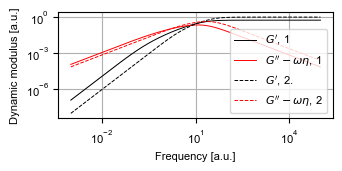

In [22]:
#compare two conditions (e.g., with and without inter-arm potentials)

#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(7/2.54,7/2.54))
fig=plt.figure(figsize=(9/2.54,3.5/2.54))

ax1 = fig.add_subplot(111)
linestyle=["-","--",":","-."]
k=0
labels_1=[r"$G'$, 1",r"$G'$, 2.",r"$G'$, 3"]
labels_2=[r"$G''-\omega \eta$, 1",r"$G''-\omega \eta$, 2",r"$G''-\omega \eta$, 3"]
for i in [0,-1]: #[2,3]
    
    
    mean_storage_mod_all_sims_ex1=np.mean(storage_mod_all_sims_all[i],axis=0)
    std_e_storage_mod_all_sims_ex1=np.std(storage_mod_all_sims_all[i],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[i])))
    
    
    mean_loss_mod_all_sims_ex1=np.mean(loss_mod_all_sims_all[i],axis=0)
    std_e_loss_mod_all_sims_ex1=np.std(loss_mod_all_sims_all[i],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[i])))
    
    ax1.errorbar(omega_t_sim1[::],mean_storage_mod_all_sims_ex1[::],fmt=linestyle[k],label=labels_1[k],color="black",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_storage_mod_all_sims_ex1[::] - std_e_storage_mod_all_sims_ex1[::], mean_storage_mod_all_sims_ex1[::] + std_e_storage_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="black")
    
    
    ax1.errorbar(omega_t_sim1[::],mean_loss_mod_all_sims_ex1[::],fmt=linestyle[k],label=labels_2[k],color="red",linewidth=0.7)
    ax1.fill_between(omega_t_sim1[::], mean_loss_mod_all_sims_ex1[::] - std_e_loss_mod_all_sims_ex1[::], mean_loss_mod_all_sims_ex1[::] + std_e_loss_mod_all_sims_ex1[::], alpha = 0.3 ,facecolor="red")
    
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**2, label=r"$\omega^2$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$")
    #ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**0.5 , label=r"$\omega^{0.5}$")
    #ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$")
    k=k+1
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**-6,2)
#plt.xlim(10**-3,10**3)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_normal_soft_2_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

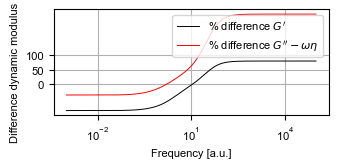

In [23]:
#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(9/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)
linestyle=["-","--",":"]


ex1=0  #2
ex2=-1   #3

diff_mean_storage=np.mean(storage_mod_all_sims_all[ex1],axis=0)-np.mean(storage_mod_all_sims_all[ex2],axis=0)
diff_mean_storage=-diff_mean_storage/np.mean(storage_mod_all_sims_all[ex1],axis=0) *100

diff_mean_loss=np.mean(loss_mod_all_sims_all[ex1],axis=0)-np.mean(loss_mod_all_sims_all[ex2],axis=0)
diff_mean_loss=-diff_mean_loss/np.mean(loss_mod_all_sims_all[ex1],axis=0) *100


err_diff_mean_loss=np.sqrt( (np.std(loss_mod_all_sims_all[ex1],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[ex1]))))**2 + (np.std(loss_mod_all_sims_all[ex2],axis=0)/(np.sqrt(len(loss_mod_all_sims_all[ex2]))))**2 )

err_diff_mean_storage=np.sqrt( (np.std(storage_mod_all_sims_all[ex1],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[ex1]))))**2 + (np.std(storage_mod_all_sims_all[ex2],axis=0)/(np.sqrt(len(storage_mod_all_sims_all[ex2]))))**2 )


ax1.errorbar(omega_t_sim1[::],diff_mean_storage[::],fmt="-",label=r"% difference $G'$",color="black",linewidth=0.7)
ax1.fill_between(omega_t_sim1[::], diff_mean_storage[::] + err_diff_mean_storage[::], diff_mean_storage[::] - err_diff_mean_storage[::], alpha = 0.3 ,facecolor="black")


ax1.errorbar(omega_t_sim1[::],diff_mean_loss[::],fmt="-",label=r"% difference $G''-\omega \eta$",color="red",linewidth=0.7)
ax1.fill_between(omega_t_sim1[::], diff_mean_loss[::] + err_diff_mean_loss[::], diff_mean_loss[::] - err_diff_mean_loss[::], alpha = 0.3 ,facecolor="red")


fs1=8
plt.xscale("log")
#plt.yscale("log")
plt.grid()
#plt.ylim(10**-6,2)
#plt.xlim(10**-3,10**3)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
plt.yticks([0,50,100],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Difference dynamic modulus [%]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_difference_normal_soft_2_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [73]:
traj_mech2=readdy.Trajectory(folder_names_dyn_mod[1][0])

time_obs_top_mech2,obs_top_mech2=traj_mech2.read_observable_topologies()
storage_mod_avg_t_nc,storage_mod_stde_t_nc,loss_mod_avg_t_nc,loss_mod_stde_t_nc,relaxation_mod_avg_t_nc,relaxation_mod_stde_t_nc,conn_mat_all_t,eigv_all_t,tau_all_t=get_time_avg_storage_loss_mod(obs_top=obs_top_mech2,time_step=15,time_skip=2250,omega_t=omega_t_sim1,t=t_sim1,edges_centre=4,edges_linker=3,cutoff_zero_eigv=10**-15,zeta=1,b=1,k=1,T=1,phi=1)


In [101]:
#test out the influence of adding relaxation times
tau_1=[e for e in tau_all_t[0]]
tau_1.append(10**50)
tau_1=np.array(tau_1)
sm1=storage_mod(phi=1,k=1,T=1,N=100,b=1,tau=tau_1,omega=omega_t_sim1)
lm1=loss_mod_deref(phi=1,k=1,T=1,N=100,b=1,tau=tau_1,omega=omega_t_sim1)

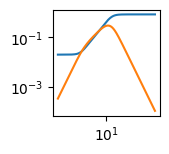

In [102]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(omega_t_sim1,sm1)
ax1.errorbar(omega_t_sim1,lm1)

plt.yscale("log")
plt.xscale("log")

# Compare angles from optimised and soft sims

CPU times: user 182 ms, sys: 1.07 s, total: 1.25 s
Wall time: 5.62 s


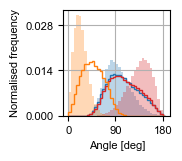

In [24]:
%%time

#guess parameter in middle of range
#folder_names_init_sim="ML_parameter_opt_1/NCG_X_motif_4/unopt_test_2/"
#names_ini1="x_test_1_"

#sim from optimization
folder_names_init_sim="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/1_motif_SE/"
names_ini1="x_c_mech_opt_angle_test_"

#opt simulations
folder_names_opt_sim1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/opt_test_1/"
#folder_names_opt_sim2="ML_parameter_opt_1/NCG_X_motif_3/opt_test_2/"
#folder_names_opt_sim3="ML_parameter_opt_1/NCG_X_motif_3/opt_test_3/"

names_opt1="x_opt_test_1_"
#names_opt2="x_opt_test_2_"
#names_opt3="x_opt_test_3_"

names_angle_eval=[[names_ini1+str(l+0)+".h5" for l in range(5)]
                 ,[names_opt1+str(l+0)+".h5" for l in range(5)]]

folders_angle_eval=[folder_names_init_sim,
                   folder_names_opt_sim1]

colours_l=["tab:blue","tab:blue"]
colours_l2=["tab:red","tab:red"]
colours_l3=["tab:orange","tab:orange"]
names_l=["First prediction","Optimised"]
histtype=["step","bar"]
alpha=[1,0.3]

fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54)) 
ax1 = fig1.add_subplot(111)
#sel_target_angle_distr=ax1.hist(values_angle_base_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]


for i in range(len(names_angle_eval)):
    base_angle_distr_ex_1,link_angle_distr_ex_1,arm_axis_angle_distr_ex_1,oppa_angle_distr_ex_1     ,values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1=cg_angle_distr_c1_4_ba_aa_oa_la(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)
    list_angles_eval=[values_angle_base_ex_1,values_angle_link_ex_1,values_angle_arm_axis_ex_1,values_angle_oppa_ex_test_1]

    sel_angle_distr=ax1.hist(values_angle_base_ex_1*180/np.pi,bins=np.arange(0,190,5),density=True, color=colours_l[i],histtype=histtype[i],label=names_l[i],alpha=alpha[i])[0]

    sel_angle_distr2=ax1.hist(values_angle_oppa_ex_test_1*180/np.pi,bins=np.arange(0,190,5),density=True, color=colours_l2[i],histtype=histtype[i],label=names_l[i],alpha=alpha[i])[0]
    




#sim from optimization
folder_names_init_sim="/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/2_motifs_bound/"
names_ini1="x_c_mech_opt_angle_test_bound_"

#opt simulations
folder_names_opt_sim1="/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/opt_test_1/"
#folder_names_opt_sim2="ML_parameter_opt_1/NCG_X_motif_3/opt_test_2/"
#folder_names_opt_sim3="ML_parameter_opt_1/NCG_X_motif_3/opt_test_3/"

names_opt1="x_opt_test_ba_1_"
#names_opt2="x_opt_test_ba_2_"
#names_opt3="x_opt_test_ba_3_"

names_angle_eval=[[names_ini1+str(l+0)+".h5" for l in range(5)]
                 ,[names_opt1+str(l+0)+".h5" for l in range(5)]]

folders_angle_eval=[folder_names_init_sim,
                   folder_names_opt_sim1]


#sel_target_angle_distr=ax1.hist(values_angle_ds_fused_link_target*180/np.pi,bins=np.arange(0,190,5),density=True, histtype='bar',ls="-",color="grey",label="Target")[0]

for i in range(len(names_angle_eval)):
    angle_ds_fused_link_distr_ex_1, values_angle_ds_fused_link_ex1=cg_angle_distr_c1_1_bm(folder=folders_angle_eval[i],names_sim_repeat=names_angle_eval[i],t_skip=300,t_lim=None,t_step=1)

    sel_angle_distr4=ax1.hist(values_angle_ds_fused_link_ex1*180/np.pi,bins=np.arange(0,190,5),density=True,color=colours_l3[i], histtype=histtype[i],label=names_l[i],alpha=alpha[i])[0]



fs1=8

#ax1.legend(loc="lower center",prop={'family': 'Arial','size': fs1})
ax1.set_ylabel("Normalised frequency",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Angle [deg]",fontname = "Arial",fontsize=fs1)
plt.xticks([0,90,180],fontname = "Arial",fontsize=fs1)
plt.yticks([0.00,0.014,0.028],fontname = "Arial",fontsize=fs1)
#plt.xlim(-1,50)
ax1.grid()

#plt.savefig("ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comparison_angles_normal_soft_1.pdf",format="pdf",bbox_inches="tight")




# Radial distribution function

In [68]:
#names with varying unbidning rate
folder_name_rdf_ex1=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]

folder_name_rdf_ex2=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_4/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

folder_name_rdf_ex3=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_2/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]

folder_name_rdf_ex4=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_soft_3/prod_checkpoint_"+str(e)+"/x_c_mech_opt_prod_"+str(e)+".h5" for e in [0,1,2,3,4]]


In [69]:
r1,rdf1_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex1,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=5250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


In [70]:
r2,rdf2_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex2,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=2250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


In [71]:
r3,rdf3_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex3,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=2250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


In [72]:
r4,rdf4_t_rep=mean_rdf_repeats(file_names=folder_name_rdf_ex4,box_length=69.718, r_max=50, dr=0.1,type_particle=53,t_skip=11250,t_step=15,t_stop=None)

x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51
x_centre_c1
51


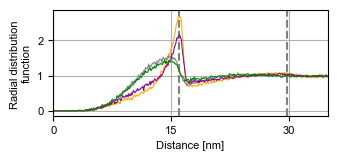

In [73]:
fig=plt.figure(figsize=(9/2.54,3.5/2.54))
ax1 = fig.add_subplot(111)

mean_rdf1_t_rep=np.mean(rdf1_t_rep,axis=0)
std_e_rdf1_t_rep=np.std(rdf1_t_rep,axis=0)/(np.sqrt(rdf1_t_rep.shape[0]))

mean_rdf2_t_rep=np.mean(rdf2_t_rep,axis=0)
std_e_rdf2_t_rep=np.std(rdf2_t_rep,axis=0)/(np.sqrt(rdf2_t_rep.shape[0]))

mean_rdf3_t_rep=np.mean(rdf3_t_rep,axis=0)
std_e_rdf3_t_rep=np.std(rdf3_t_rep,axis=0)/(np.sqrt(rdf3_t_rep.shape[0]))

mean_rdf4_t_rep=np.mean(rdf4_t_rep,axis=0)
std_e_rdf4_t_rep=np.std(rdf4_t_rep,axis=0)/(np.sqrt(rdf4_t_rep.shape[0]))

step_l1=1
ax1.errorbar(r1[::step_l1],mean_rdf1_t_rep[::step_l1],color="orange",label=r"$r_{Split} \cdot \Delta t=0$",linewidth=0.7)
ax1.fill_between(r1, mean_rdf1_t_rep[::] + std_e_rdf1_t_rep[::], mean_rdf1_t_rep[::] - std_e_rdf1_t_rep[::], alpha = 0.3 ,facecolor="orange")

ax1.errorbar(r4[::step_l1],mean_rdf4_t_rep[::step_l1],color="grey",label=r"$r_{Split}\cdot \Delta t=0$, no inter-arm pot.",linewidth=0.7)
ax1.fill_between(r4, mean_rdf4_t_rep[::] + std_e_rdf4_t_rep[::], mean_rdf4_t_rep[::] - std_e_rdf4_t_rep[::], alpha = 0.3 ,facecolor="grey")

ax1.errorbar(r1[::step_l1],mean_rdf2_t_rep[::step_l1],color="purple",label=r"$r_{Split}\cdot \Delta t=5\cdot 10^{-6}$",linewidth=0.7)
ax1.fill_between(r1, mean_rdf2_t_rep[::] + std_e_rdf2_t_rep[::], mean_rdf2_t_rep[::] - std_e_rdf2_t_rep[::], alpha = 0.3 ,facecolor="purple")

ax1.errorbar(r1[::step_l1],mean_rdf3_t_rep[::step_l1],color="green",label=r"$r_{Split}\cdot \Delta t=5\cdot 10^{-6}$, no inter-arm pot.",linewidth=0.7)
ax1.fill_between(r1, mean_rdf3_t_rep[::] + std_e_rdf3_t_rep[::], mean_rdf3_t_rep[::] - std_e_rdf3_t_rep[::], alpha = 0.3 ,facecolor="green")





fs1=8
plt.xlim(0,35)
plt.xticks([0,15,30],fontname = "Arial",fontsize=fs1)
plt.yticks([0,1,2],fontname = "Arial",fontsize=fs1)

plt.ylabel("Radial distribution \nfunction",fontname = "Arial",fontsize=fs1)
plt.xlabel("Distance [nm]",fontname = "Arial",fontsize=fs1)
plt.grid()


#plt.axhline(1)
plt.axvline(16,color="grey",linestyle="--",label="16 nm")
plt.axvline(29.8,color="grey",linestyle="--",label="16 nm")

#ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/rad_ditr_fct_comp_2.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
#plt.hlines(1,0,80)

In [ ]:
peaks,_=scipy.signal.find_peaks(mean_rdf1_t_rep, prominence=0.1)
print(peaks)
print(r1[peaks])

# Get intra-chain mod

12


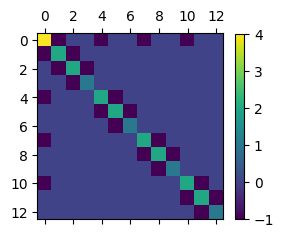

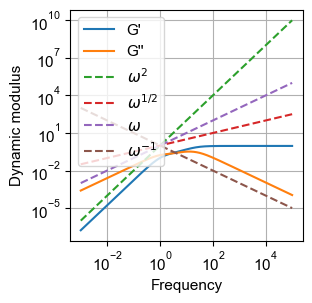

In [8]:
def calculate_graph_laplacian(edges, num_nodes):
    # Initialize the adjacency matrix
    adjacency_matrix = np.zeros((num_nodes, num_nodes))
    
    # Fill the adjacency matrix based on the edges
    for edge in edges:
        i, j = edge
        adjacency_matrix[i, j] = 1
        adjacency_matrix[j, i] = 1
    
    # Degree matrix
    degree_matrix = np.diag(np.sum(adjacency_matrix, axis=1))
    
    # Laplacian matrix
    laplacian_matrix = degree_matrix - adjacency_matrix
    
    return laplacian_matrix


conn_matrix_intra_1=calculate_graph_laplacian(edges=[(0, 1), (1, 2), (2, 3), (0, 4), (4, 5), (5, 6), (0, 7), (7, 8), (8, 9), (0, 10), (10, 11), (11, 12)],num_nodes=13)

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
cax1=ax1.matshow(conn_matrix_intra_1, cmap='viridis')
fig1.colorbar(cax1,shrink=0.8)

eigenvalues_intra_1, eigenvectors_intra_1 = np.linalg.eig(conn_matrix_intra_1)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_intra_1_nz=np.array([e for e in eigenvalues_intra_1 if abs(e)>10**-9])
tau_intra_1=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_intra_1_nz)
print(len(tau_intra_1))

#get storage mod and loss mod
#omega_intra_1=np.geomspace(10**-2,10**4,10**4)
#t_intra_1=np.geomspace(10**-2,10**3,10**4)

storage_mod_intra_1=storage_mod(phi=1,k=1,T=1,N=13,b=1,tau=tau_intra_1[:],omega=omega_t_sim1)
loss_mod_intra_1=loss_mod_deref(phi=1,k=1,T=1,N=13,b=1,tau=tau_intra_1[:],omega=omega_t_sim1)
relaxation_mod_intra_1=relaxation_mod(phi=1,k=1,T=1,N=13,b=1,tau=tau_intra_1[:],t=t_sim1)
storage_mod_intra_1=[x.real if isinstance(x, complex) else x for x in storage_mod_intra_1]
loss_mod_intra_1=[x.real if isinstance(x, complex) else x for x in loss_mod_intra_1]
relaxation_mod_intra_1=[x.real if isinstance(x, complex) else x for x in relaxation_mod_intra_1]

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_intra_1,fmt="-",label="G'")
ax1.errorbar(omega_t_sim1,loss_mod_intra_1,fmt="-",label="G''")

omega_intra_2=np.geomspace(10**0,10**2,10**3)
ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
ax1.set_ylabel("Dynamic modulus",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Frequency",fontname = "Arial",fontsize=11)
ax1.legend(loc="upper left",prop={'family': 'Arial','size': 11})

# Generate theoretical graphs of networked materials

8.0
6


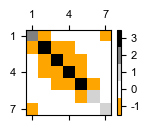

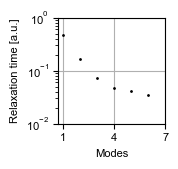

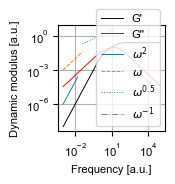

In [9]:
#example graph, relaxation times and moduli

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)
fs1=8
num_nodes_ilu_1=24
#conn_matrix_gen_ilu_1=generate_rd_graph_laplacian2_b(N=num_nodes_ilu_1, m=4, p=30,rs=4)

conn_matrix_gen_ilu_1=generate_laplacian_from_edges([[0,1],[1,2],[2,3],[3,4],[1,3],[2,4],[4,5],[0,6]])

#edges_test_1=[[i,i+1] for i in range(1000)]
#conn_matrix_gen_ilu_1=generate_laplacian_from_edges(edges_test_1)

print(0.5*np.trace(conn_matrix_gen_ilu_1))
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig1.add_subplot(111)


from matplotlib.colors import ListedColormap,BoundaryNorm
# You can also use: ListedColormap(plt.cm.tab10.colors[:5])
cmap = ListedColormap(["orange", "white", "lightgrey", "grey", "black"])

cax1=ax1.matshow(conn_matrix_gen_ilu_1, cmap=cmap)


bounds  = np.array([-1.5, -0.5, 0.5, 1.5, 2.5, 3.5])  # 6 edges → 5 bins
centers = (bounds[:-1] + bounds[1:]) / 2               # → [-1, 0, 1, 2, 3]
labels  = ['-1', '0', '1', '2', '3']

norm = BoundaryNorm(bounds, cmap.N, clip=True)

cbar = plt.colorbar(cax1, shrink=0.8, ticks=centers,boundaries=bounds)

cbar.ax.set_yticklabels(labels)  # vertical by default

cbar.ax.tick_params(labelsize=fs1,labelfontfamily = "Arial")

############
#cbar = plt.colorbar(cax1,shrink=0.8)
#cbar.set_ticks([-1,0,1,2,3])
#cbar.ax.tick_params(labelsize=fs1,labelfontfamily = "Arial")
##############

plt.yticks([0,3,6],[1,4,7],fontname = "Arial",fontsize=fs1)
plt.xticks([0,3,6],[1,4,7],fontname = "Arial",fontsize=fs1)

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/graph_laplacian_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


eigenvalues_gen_ilu_1, eigenvectors_gen_ilu_1 = np.linalg.eig(conn_matrix_gen_ilu_1)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_gen_ilu_1_nz=np.array([e for e in eigenvalues_gen_ilu_1 if abs(e)>10**-9])
tau_gen_ilu_1=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_gen_ilu_1_nz)
print(len(tau_gen_ilu_1))

#get storage mod and loss mod
#omega_gen_ilu_1=np.geomspace(10**-2,10**4,10**4)
#t_gen_ilu_1=np.geomspace(10**-2,10**3,10**4)

storage_mod_gen_ilu_1=storage_mod(phi=1,k=1,T=1,N=num_nodes_ilu_1,b=1,tau=tau_gen_ilu_1[:],omega=omega_t_sim1)
loss_mod_gen_ilu_1=loss_mod_deref(phi=1,k=1,T=1,N=num_nodes_ilu_1,b=1,tau=tau_gen_ilu_1[:],omega=omega_t_sim1)
relaxation_mod_gen_ilu_1=relaxation_mod(phi=1,k=1,T=1,N=num_nodes_ilu_1,b=1,tau=tau_gen_ilu_1[:],t=t_sim1)
storage_mod_gen_ilu_1=[x.real if isinstance(x, complex) else x for x in storage_mod_gen_ilu_1]
loss_mod_gen_ilu_1=[x.real if isinstance(x, complex) else x for x in loss_mod_gen_ilu_1]
relaxation_mod_gen_ilu_1=[x.real if isinstance(x, complex) else x for x in relaxation_mod_gen_ilu_1]


sorted_tau_test=sorted(tau_gen_ilu_1,reverse=True)
modes_test=np.arange(1,len(sorted_tau_test)+1)
fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig1.add_subplot(111)
ax1.errorbar(modes_test,sorted_tau_test,fmt=".",markersize=2,color="black")
0
#plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks([1,4,7],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-2,10**-1,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Relaxation time [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Modes",fontname = "Arial",fontsize=fs1)

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/relax_times_graph_laplacian_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_gen_ilu_1,fmt="-",label="G'",color="black",linewidth=0.7)
ax1.errorbar(omega_t_sim1,loss_mod_gen_ilu_1,fmt="-",label="G''",color="red",linewidth=0.7)

omega_gen_rd_2=np.geomspace(10**0,10**2,10**3)
'''ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")'''

ax1.errorbar(omega_t_sim1[:150],omega_t_sim1[:150]**2, label=r"$\omega^2$",fmt="-",linewidth=0.7)
ax1.errorbar(omega_t_sim1[:200],omega_t_sim1[:200]**1 , label=r"$\omega$",fmt="--",linewidth=0.7)
ax1.errorbar(omega_t_sim1[200:500],omega_t_sim1[200:500]**0.5 , label=r"$\omega^{0.5}$",fmt=":",linewidth=0.7)
ax1.errorbar(omega_t_sim1[700:],omega_t_sim1[700:]**-1 , label=r"$\omega^{-1}$",fmt="-.",color="grey",linewidth=0.7)

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(loc="lower right",prop={'family': 'Arial','size': fs1})
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/moduli_graph_laplacian_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")


200.0
99
200.0
99


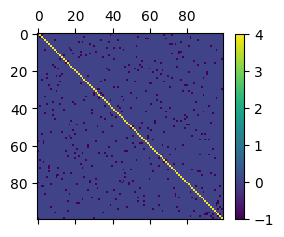

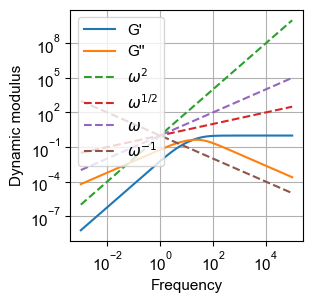

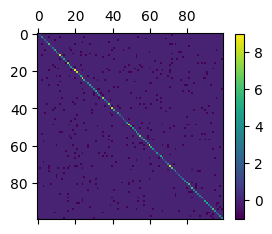

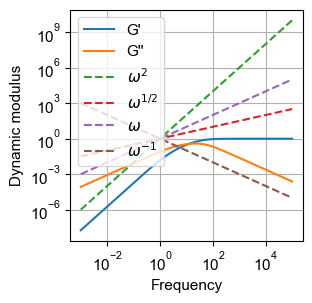

In [10]:

#generate theoretical graphs


#graph of 100, 4-armed nanomotifs, with all 4 armes connected to other nanomotifs
num_nodes_rd_1=100
conn_matrix_gen_rd_1=generate_rd_graph_laplacian2_b(N=num_nodes_rd_1, m=4, p=200,rs=1)
print(0.5*np.trace(conn_matrix_gen_rd_1))
fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
cax1=ax1.matshow(conn_matrix_gen_rd_1, cmap='viridis')
fig1.colorbar(cax1,shrink=0.8)

eigenvalues_gen_rd_1, eigenvectors_gen_rd_1 = np.linalg.eig(conn_matrix_gen_rd_1)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_gen_rd_1_nz=np.array([e for e in eigenvalues_gen_rd_1 if abs(e)>10**-9])
tau_gen_rd_1=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_gen_rd_1_nz)
print(len(tau_gen_rd_1))

#get storage mod and loss mod
#omega_gen_rd_1=np.geomspace(10**-2,10**4,10**4)
#t_gen_rd_1=np.geomspace(10**-2,10**3,10**4)

storage_mod_gen_rd_1=storage_mod(phi=1,k=1,T=1,N=num_nodes_rd_1,b=1,tau=tau_gen_rd_1[:],omega=omega_t_sim1)
loss_mod_gen_rd_1=loss_mod_deref(phi=1,k=1,T=1,N=num_nodes_rd_1,b=1,tau=tau_gen_rd_1[:],omega=omega_t_sim1)
relaxation_mod_gen_rd_1=relaxation_mod(phi=1,k=1,T=1,N=num_nodes_rd_1,b=1,tau=tau_gen_rd_1[:],t=t_sim1)
storage_mod_gen_rd_1=[x.real if isinstance(x, complex) else x for x in storage_mod_gen_rd_1]
loss_mod_gen_rd_1=[x.real if isinstance(x, complex) else x for x in loss_mod_gen_rd_1]
relaxation_mod_gen_rd_1=[x.real if isinstance(x, complex) else x for x in relaxation_mod_gen_rd_1]

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_gen_rd_1,fmt="-",label="G'")
ax1.errorbar(omega_t_sim1,loss_mod_gen_rd_1,fmt="-",label="G''")

omega_gen_rd_2=np.geomspace(10**0,10**2,10**3)
ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
ax1.set_ylabel("Dynamic modulus",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Frequency",fontname = "Arial",fontsize=11)
ax1.legend(loc="upper left",prop={'family': 'Arial','size': 11})




################################
################################
################################
################################
################################
################################


#graph of 100, motifs with maximum degree 99 and same number of edges as for the 4-armed systems

num_nodes_rd_2=100
conn_matrix_gen_rd_2=generate_rd_graph_laplacian2_b(N=num_nodes_rd_2, m=99, p=200,rs=1)
print(0.5*np.trace(conn_matrix_gen_rd_2))
fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
cax1=ax1.matshow(conn_matrix_gen_rd_2, cmap='viridis')
fig1.colorbar(cax1,shrink=0.8)

eigenvalues_gen_rd_2, eigenvectors_gen_rd_2 = np.linalg.eig(conn_matrix_gen_rd_2)



#get relaxation times for non-zero eigenvalues
#!! sometimes very small eigenvalues are calculated that should probably be zero, for instance for graph laplacian for N monomers, only N-1 non-zero eigenvalues exist
eigenvalues_gen_rd_2_nz=np.array([e for e in eigenvalues_gen_rd_2 if abs(e)>10**-9])
tau_gen_rd_2=relax_times(zeta=1,b=1,k=1,T=1,eigv_lambda=eigenvalues_gen_rd_2_nz)
print(len(tau_gen_rd_2))

#get storage mod and loss mod
#omega_gen_rd_2=np.geomspace(10**-2,10**4,10**4)
#t_gen_rd_2=np.geomspace(10**-2,10**3,10**4)

storage_mod_gen_rd_2=storage_mod(phi=1,k=1,T=1,N=num_nodes_rd_2,b=1,tau=tau_gen_rd_2[:],omega=omega_t_sim1)
loss_mod_gen_rd_2=loss_mod_deref(phi=1,k=1,T=1,N=num_nodes_rd_2,b=1,tau=tau_gen_rd_2[:],omega=omega_t_sim1)
relaxation_mod_gen_rd_2=relaxation_mod(phi=1,k=1,T=1,N=num_nodes_rd_2,b=1,tau=tau_gen_rd_2[:],t=t_sim1)
storage_mod_gen_rd_2=[x.real if isinstance(x, complex) else x for x in storage_mod_gen_rd_2]
loss_mod_gen_rd_2=[x.real if isinstance(x, complex) else x for x in loss_mod_gen_rd_2]
relaxation_mod_gen_rd_2=[x.real if isinstance(x, complex) else x for x in relaxation_mod_gen_rd_2]

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)

ax1.errorbar(omega_t_sim1,storage_mod_gen_rd_2,fmt="-",label="G'")
ax1.errorbar(omega_t_sim1,loss_mod_gen_rd_2,fmt="-",label="G''")

omega_gen_rd_2=np.geomspace(10**0,10**2,10**3)
ax1.errorbar(omega_t_sim1,omega_t_sim1**2,label=r"$\omega^2$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**0.5,label=r"$\omega^{1/2}$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**1,label=r"$\omega$",fmt="--")
ax1.errorbar(omega_t_sim1,omega_t_sim1**-1,label=r"$\omega^{-1}$",fmt="--")

plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=11)
plt.yticks(fontname = "Arial",fontsize=11)
ax1.set_ylabel("Dynamic modulus",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Frequency",fontname = "Arial",fontsize=11)
ax1.legend(loc="upper left",prop={'family': 'Arial','size': 11})






# Compare moduli to experimental data

Experimental bulk rheology data was provided by Nathaniel Conrad and is described in Conrad et al Increasing valence pushes DNA nanostar networks to the isostatic point, PNAS, 2019

Additional micro rheology data was generated in Palombo et al Topological linking determines elasticity in limited valence networks, Nat. Materials, 2025. Data was made available with publication. 

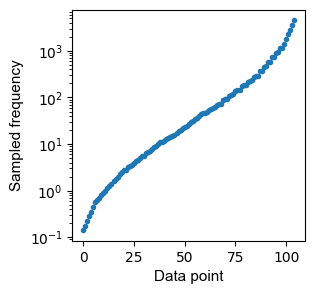

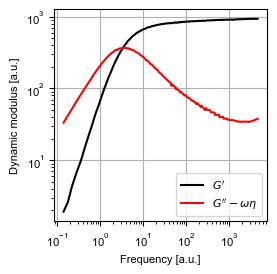

In [11]:
#Exp. data from Conrad et al for 4-armed motif
exp_data_dyn_mod=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/FrequencySweep_4ArmDNAns_490uM.csv",sep=",",header=None)
exp_data_dyn_mod.columns=["freq.","G'","G''"]

freq=exp_data_dyn_mod["freq."].to_numpy()

G_storage_exp=exp_data_dyn_mod["G'"].to_numpy()
G_loss_exp=exp_data_dyn_mod["G''"].to_numpy()

fig1=plt.figure(figsize=(3,3))
ax1 = fig1.add_subplot(111)
ax1.errorbar(np.arange(len(freq)),freq,fmt=".")
ax1.set_ylabel("Sampled frequency",fontname = "Arial",fontsize=11)
ax1.set_xlabel("Data point",fontname = "Arial",fontsize=11)
plt.yscale("log")

#fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(7/2.54,7/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$",color="black")


ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''-\omega \eta$",color="red")


fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**-6,2)
#plt.xlim(10**-3,10**3)
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")
#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/dyn_mod_ub_rate_ex_"+str(i)+"_1.pdf"
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

In [12]:
#load in sim data for 4-armed motif

omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)


#load in new
folder_name_ex_c=["/mnt/d/D_phd/D_Nanomotif_Coarse_Graining_1/D_ML_parameter_opt_1/D_NCG_X_motif_conrad_1/D_shear_mod_2/prod_cont_2_checkpoint_"+str(e)+"/x_c_mech_opt_prod_cont_2_"+str(e)+".h5" for e in [0,1,2,3,4]]

#####storage_mod_all_sims_ex_c,loss_mod_all_sims_ex_c=avg_moduli_1(folder_names=folder_name_ex_c,omega_t_sim1=omega_t_sim1,t_sim1=t_sim1,b_u=1,zeta_u=1,k_u=1,T_u=1,phi_u=1,time_step=15,time_skip=5250)
#storage_mod_all_sims_ex_c,loss_mod_all_sims_ex_c,conn_mat_sim_ex_c=avg_moduli_3(folder_names=folder_name_ex_c,omega_t_sim1=omega_t_sim1,t_sim1=t_sim1,b_u=1,zeta_u=1,k_u=1,T_u=1,phi_u=1,time_step=15,time_skip=5250)

#use previous load in

storage_mod_all_sims_ex_c=storage_mod_all_sims_all[-1]
loss_mod_all_sims_ex_c=loss_mod_all_sims_all[-1]

storage_mod_all_t_avg_comp_mean=np.mean(storage_mod_all_sims_ex_c,axis=0)
loss_mod_all_t_avg_comp_mean=np.mean(loss_mod_all_sims_ex_c,axis=0)

storage_mod_all_t_avg_comp_stde=np.std(storage_mod_all_sims_ex_c,axis=0)/np.sqrt(len(storage_mod_all_sims_ex_c))
loss_mod_all_t_avg_comp_stde=np.std(loss_mod_all_sims_ex_c,axis=0)/np.sqrt(len(loss_mod_all_sims_ex_c))

In [25]:
#rescale simulation data by matching cross over point to experimental data
#omega_inters_target_1=3.1 #8
#dyn_mod_inters_target_1=390  #95
#dataset 1
omega_inters_target_1,dyn_mod_inters_target_1=find_intersection(x1=freq, y1=G_storage_exp, x2=freq, y2=G_loss_exp)[0]
print("Intersection exp dataset 1:","omega:",omega_inters_target_1,"dynamic mod.", dyn_mod_inters_target_1)


omega_inters_1,dyn_mod_inters_1=find_intersection(x1=omega_t_sim1, y1=storage_mod_all_t_avg_comp_mean, x2=omega_t_sim1, y2=loss_mod_all_t_avg_comp_mean)[0]
print("Intersection sim dataset 1:","omega:",omega_inters_1,"dynamic mod.", dyn_mod_inters_1)

omega_t_sim1_shift=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_1
storage_mod_sim1_avg_t_shift=np.array(storage_mod_all_t_avg_comp_mean)*dyn_mod_inters_target_1/dyn_mod_inters_1
loss_mod_sim1_avg_t_shift=np.array(loss_mod_all_t_avg_comp_mean)*dyn_mod_inters_target_1/dyn_mod_inters_1

storage_mod_all_t_avg_comp_stde_shift=np.array(storage_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1
loss_mod_all_t_avg_comp_stde_shift=np.array(loss_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1



#combination of intra and inter chain moduli
frac_inter=0.88
storage_mod_all_t_avg_comp_mean_comb=frac_inter*np.array(storage_mod_all_t_avg_comp_mean)+(1-frac_inter)*np.array(storage_mod_intra_1)
loss_mod_all_t_avg_comp_mean_comb=frac_inter*np.array(loss_mod_all_t_avg_comp_mean)+(1-frac_inter)*np.array(loss_mod_intra_1)

omega_inters_2,dyn_mod_inters_2=find_intersection(x1=omega_t_sim1, y1=storage_mod_all_t_avg_comp_mean_comb, x2=omega_t_sim1, y2=loss_mod_all_t_avg_comp_mean_comb)[0]
print("Intersection sim dataset 1:","omega:",omega_inters_2,"dynamic mod.", dyn_mod_inters_2)

omega_t_sim1_shift_comb=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_2

storage_mod_sim1_avg_t_shift_comb=np.array(storage_mod_all_t_avg_comp_mean_comb)*dyn_mod_inters_target_1/dyn_mod_inters_2
loss_mod_sim1_avg_t_shift_comb=np.array(loss_mod_all_t_avg_comp_mean_comb)*dyn_mod_inters_target_1/dyn_mod_inters_2


#single relaxation time

storage_mod_r1=storage_mod(phi=1,k=1,T=1,N=1,b=1,tau=np.array([1]),omega=omega_t_sim1)
loss_mod_r1=loss_mod_deref(phi=1,k=1,T=1,N=1,b=1,tau=np.array([1]),omega=omega_t_sim1)

omega_inters_3,dyn_mod_inters_3=find_intersection(x1=omega_t_sim1, y1=storage_mod_r1, x2=omega_t_sim1, y2=loss_mod_r1)[0]
print("Intersection sim dataset 1:","omega:",omega_inters_3,"dynamic mod.", dyn_mod_inters_3)
omega_t_sim1_shift_r1=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_3

storage_mod_r1_shift=np.array(storage_mod_r1)*dyn_mod_inters_target_1/dyn_mod_inters_3
loss_mod_r1_shift=np.array(loss_mod_r1)*dyn_mod_inters_target_1/dyn_mod_inters_3

#artificial graph laplacian 1

omega_inters_4,dyn_mod_inters_4=find_intersection(x1=omega_t_sim1, y1=storage_mod_gen_rd_1, x2=omega_t_sim1, y2=loss_mod_gen_rd_1)[0]

storage_mod_gen_rd_1_shift=np.array(storage_mod_gen_rd_1)*dyn_mod_inters_target_1/dyn_mod_inters_4
loss_mod_gen_rd_1_shift=np.array(loss_mod_gen_rd_1)*dyn_mod_inters_target_1/dyn_mod_inters_4

print("Intersection sim dataset 1:","omega:",omega_inters_4,"dynamic mod.", dyn_mod_inters_4)
omega_t_sim1_shift_rd_1=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_4

#storage_mod_all_t_avg_comp_stde_shift=np.array(storage_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1
#loss_mod_all_t_avg_comp_stde_shift=np.array(loss_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1

#artificial graph laplacian 2

omega_inters_5,dyn_mod_inters_5=find_intersection(x1=omega_t_sim1, y1=storage_mod_gen_rd_2, x2=omega_t_sim1, y2=loss_mod_gen_rd_2)[0]

storage_mod_gen_rd_2_shift=np.array(storage_mod_gen_rd_2)*dyn_mod_inters_target_1/dyn_mod_inters_5
loss_mod_gen_rd_2_shift=np.array(loss_mod_gen_rd_2)*dyn_mod_inters_target_1/dyn_mod_inters_5

print("Intersection sim dataset 1:","omega:",omega_inters_5,"dynamic mod.", dyn_mod_inters_5)
omega_t_sim1_shift_rd_2=np.array(omega_t_sim1)*omega_inters_target_1/omega_inters_5

#storage_mod_all_t_avg_comp_stde_shift=np.array(storage_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1
#loss_mod_all_t_avg_comp_stde_shift=np.array(loss_mod_all_t_avg_comp_stde)*dyn_mod_inters_target_1/dyn_mod_inters_1

f_eval_1=65#  65
print("G' plateau at freq",freq[f_eval_1],"exp:",G_storage_exp[f_eval_1])
print("G' plateau at freq",freq[f_eval_1],"pred. from relax. spectra from sim",np.interp(freq[f_eval_1],omega_t_sim1_shift,storage_mod_sim1_avg_t_shift))
print("G' plateau at freq",freq[f_eval_1],"pred. from 1 relax time",np.interp(freq[f_eval_1],omega_t_sim1_shift_r1,storage_mod_r1_shift))
print("G' plateau at freq",freq[f_eval_1],"pred. from relax. spectra from theo. graph",np.interp(freq[f_eval_1],omega_t_sim1_shift_rd_1,storage_mod_gen_rd_1_shift))

Intersection exp dataset 1: omega: 3.30506 dynamic mod. 359.08500000000004
Intersection sim dataset 1: omega: 15.856913514930753 dynamic mod. 0.4019545266298512
Intersection sim dataset 1: omega: 13.682157752737307 dynamic mod. 0.3795589808216674
Intersection sim dataset 1: omega: 0.9977401668339922 dynamic mod. 0.49884765500121053
Intersection sim dataset 1: omega: 17.38836298389772 dynamic mod. 0.4148540491474968
Intersection sim dataset 1: omega: 12.4771257871546 dynamic mod. 0.36454516202583953
G' plateau at freq 62.8319 exp: 826.197
G' plateau at freq 62.8319 pred. from relax. spectra from sim 869.090827110793
G' plateau at freq 62.8319 pred. from 1 relax time 717.8334375102505
G' plateau at freq 62.8319 pred. from relax. spectra from theo. graph 851.2712626299883


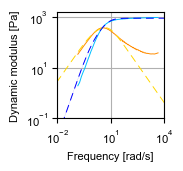

In [15]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$, exp.",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''$, exp.",color="darkorange",linewidth=0.7)
   
line1=ax1.errorbar(omega_t_sim1_shift[::],storage_mod_sim1_avg_t_shift[::],fmt=":",label=r"$G'$, sim. rescal.",color="blue",linewidth=0.7)
ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,facecolor="blue")
line1[0].set_dashes([8,5])  #[8, 5]  

#G_loss_medium=visc_T_sys=omega_t_sim1_shift*visc_T(273+20)

line2=ax1.errorbar(omega_t_sim1_shift[::],loss_mod_sim1_avg_t_shift[::],fmt=":",label=r"$G''-\omega \eta$, sim. rescal.",color="gold",linewidth=0.7)
ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,facecolor="gold")
line2[0].set_dashes([8, 5])  #[8, 5]


#ax1.errorbar(omega_t_sim1_shift,omega_t_sim1_shift*visc_T_sys,fmt="-",label=r"$\omega \cdot \eta_{medium}$",color="blue")

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_10.pdf"
save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_test.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

<Figure size 137.795x137.795 with 0 Axes>

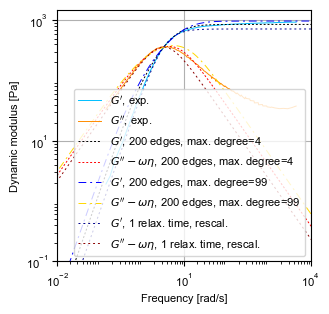

In [26]:


fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq[::],G_storage_exp[::],fmt="-",label=r"$G'$, exp.",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq[::],G_loss_exp[::],fmt="-",label=r"$G''$, exp.",color="darkorange",linewidth=0.7)
   
line1=ax1.errorbar(omega_t_sim1_shift_rd_1[::],storage_mod_gen_rd_1_shift[::],fmt=":",label=r"$G'$, 200 edges, max. degree=4 ",color="black",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="black")
line1[0].set_dashes([2,2,2,2])  

line2=ax1.errorbar(omega_t_sim1_shift_rd_1[::],loss_mod_gen_rd_1_shift[::],fmt=":",label=r"$G''-\omega \eta$, 200 edges, max. degree=4 ",color="red",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="red")
line2[0].set_dashes([2,2,2,2])  

#ax1.errorbar(omega_t_sim1_shift,omega_t_sim1_shift*visc_T_sys,fmt="-",label=r"$\omega \cdot \eta_{medium}$",color="blue")



   
line3=ax1.errorbar(omega_t_sim1_shift_rd_2[::],storage_mod_gen_rd_2_shift[::],fmt="-.",label=r"$G'$, 200 edges, max. degree=99 ",color="blue",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="black")
line3[0].set_dashes([8, 4, 2, 4])  

line4=ax1.errorbar(omega_t_sim1_shift_rd_2[::],loss_mod_gen_rd_2_shift[::],fmt="-.",label=r"$G''-\omega \eta$, 200 edges, max. degree=99 ",color="gold",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="red")
line4[0].set_dashes([8, 4, 2, 4])  



line5=ax1.errorbar(omega_t_sim1_shift_r1[::],storage_mod_r1_shift[::],fmt=":",label=r"$G'$, 1 relax. time, rescal.",color="darkblue",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], storage_mod_sim1_avg_t_shift[::] + storage_mod_all_t_avg_comp_stde_shift[::], storage_mod_sim1_avg_t_shift[::] - storage_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="black")
line5[0].set_dashes([2, 3])  

line6=ax1.errorbar(omega_t_sim1_shift_r1[::],loss_mod_r1_shift[::],fmt=":",label=r"$G''-\omega \eta$, 1 relax. time, rescal.",color="darkred",linewidth=0.7)
#ax1.fill_between(omega_t_sim1_shift[::], loss_mod_sim1_avg_t_shift[::] + loss_mod_all_t_avg_comp_stde_shift[::], loss_mod_sim1_avg_t_shift[::] - loss_mod_all_t_avg_comp_stde_shift[::], alpha = 0.3 ,color="red")
line6[0].set_dashes([2, 3])   



fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")




save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_1_3.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")




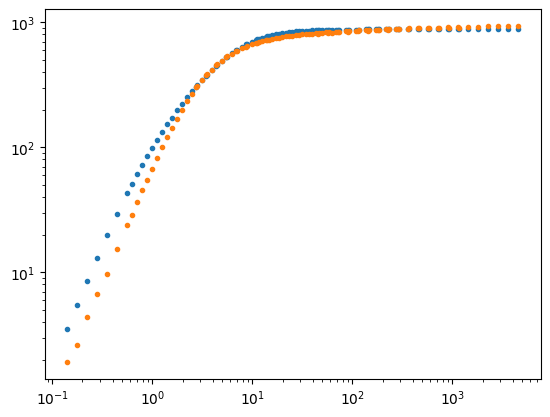

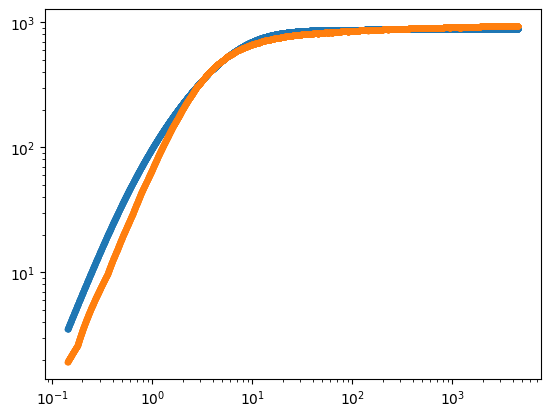

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9881868745082691
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9760587627162047
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9915648219727285
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9740207666537554
With same log spaced x range, mean absolute percentage error: 0.20736177109758727
With same log spaced x range, mean absolute log error: 0.15969213664780546
Integral mean absolute log error: 0.160765662410161


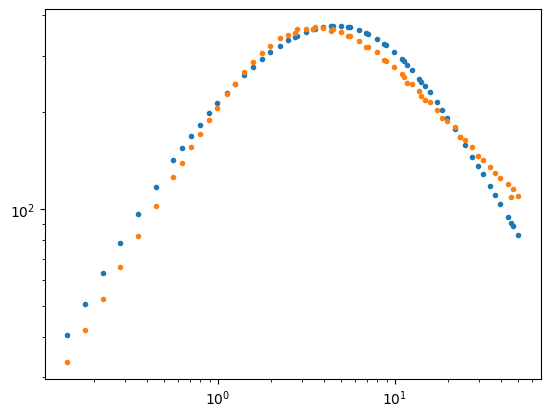

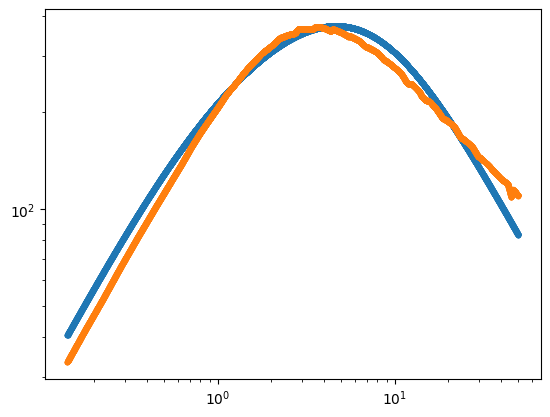

R² value between the two curves in the interval [5e-10, 50] is: 0.9629907464197307
R² value for log(y) values between the two curves in the interval [5e-10, 50] is: 0.9610885976054168
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50] is: 0.9744082572649898
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50] is: 0.970511607410172
With same log spaced x range, mean absolute percentage error: 0.09562150243032684
With same log spaced x range, mean absolute log error: 0.09228500974439426
Integral mean absolute log error: 0.09228438255681232


In [39]:
#Quantify similarity between prediction and experiment
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift,y2=storage_mod_sim1_avg_t_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift,y2=loss_mod_sim1_avg_t_shift,X_low=5* 10**-10,X_high=5* 10**1)

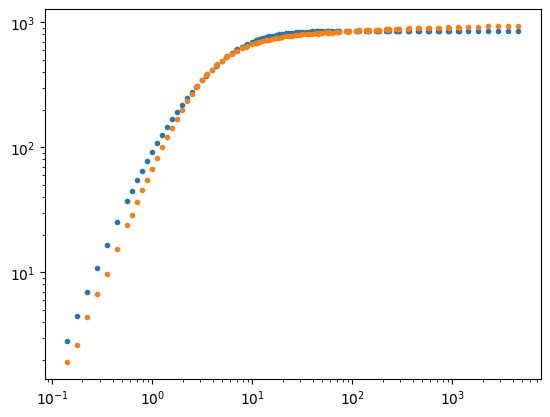

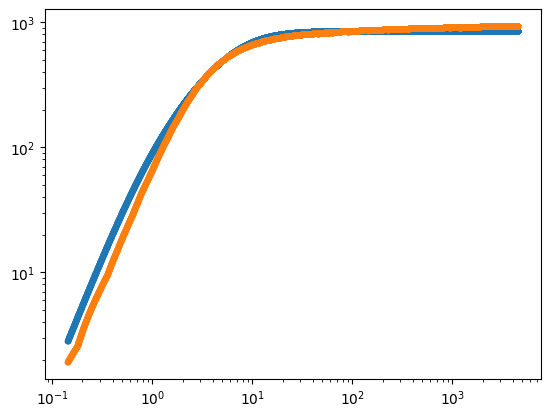

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9890168563200268
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9863017266457355
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9900499244923922
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9855058585973544
With same log spaced x range, mean absolute percentage error: 0.15255992341306232
With same log spaced x range, mean absolute log error: 0.12848532985216785
Integral mean absolute log error: 0.1295668472740065


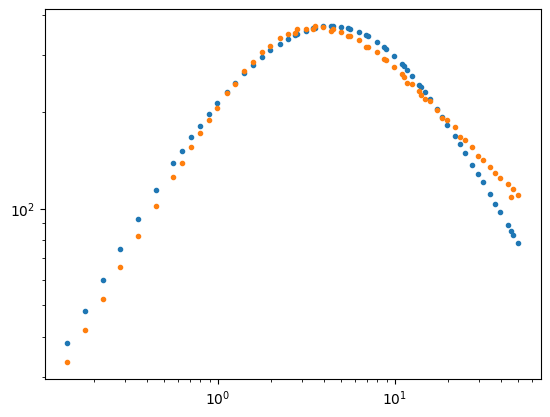

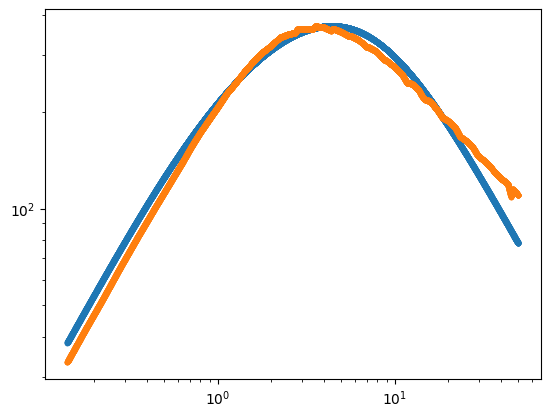

R² value between the two curves in the interval [5e-10, 50] is: 0.9723978776893296
R² value for log(y) values between the two curves in the interval [5e-10, 50] is: 0.9577218631935376
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50] is: 0.9815496047618762
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50] is: 0.9741914418353649
With same log spaced x range, mean absolute percentage error: 0.08160027887205311
With same log spaced x range, mean absolute log error: 0.08164243950335581
Integral mean absolute log error: 0.08162246029495289


In [40]:
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift_rd_1,y2=storage_mod_gen_rd_1_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift_rd_1,y2=loss_mod_gen_rd_1_shift,X_low=5* 10**-10,X_high=5* 10**1)

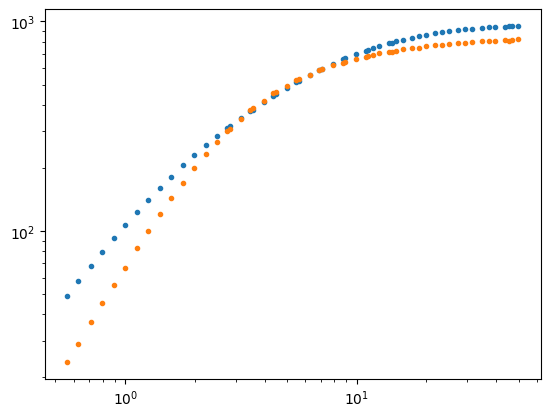

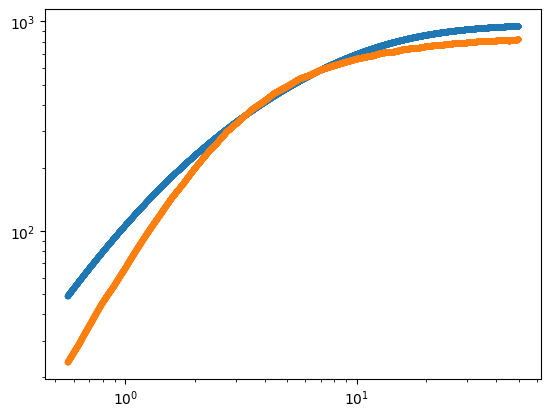

R² value between the two curves in the interval [0.5, 50] is: 0.9308898276097979
R² value for log(y) values between the two curves in the interval [0.5, 50] is: 0.9416958079643087
With same log spaced x range, R² value between the two curves in the interval [0.5, 50] is: 0.9456416997447562
With same log spaced x range, R² value for log(y) values between the two curves in the interval [0.5, 50] is: 0.9371608862169404
With same log spaced x range, mean absolute percentage error: 0.21688108734436629
With same log spaced x range, mean absolute log error: 0.17672222964583667
Integral mean absolute log error: 0.17707912750204963


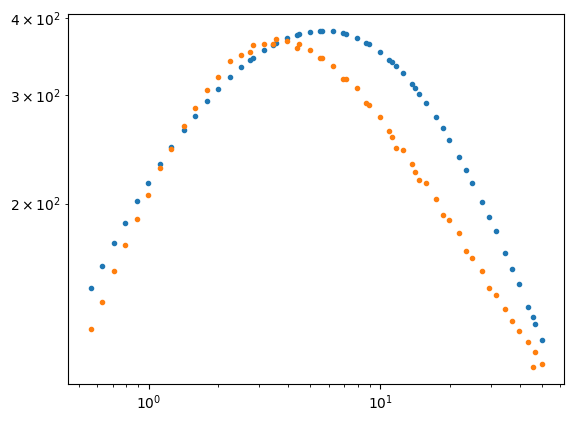

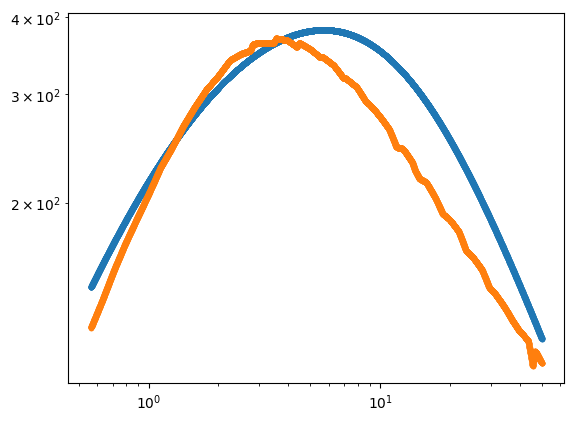

R² value between the two curves in the interval [0.5, 50] is: 0.6985141577713285
R² value for log(y) values between the two curves in the interval [0.5, 50] is: 0.7582137180016659
With same log spaced x range, R² value between the two curves in the interval [0.5, 50] is: 0.7246486597167109
With same log spaced x range, R² value for log(y) values between the two curves in the interval [0.5, 50] is: 0.7672478310876323
With same log spaced x range, mean absolute percentage error: 0.15669622270087172
With same log spaced x range, mean absolute log error: 0.14017616323298215
Integral mean absolute log error: 0.1404215662806678


In [41]:
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift_rd_2,y2=storage_mod_gen_rd_2_shift,X_low=5* 10**-1,X_high=5* 10**1)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift_rd_2,y2=loss_mod_gen_rd_2_shift,X_low=5* 10**-1,X_high=5* 10**1)

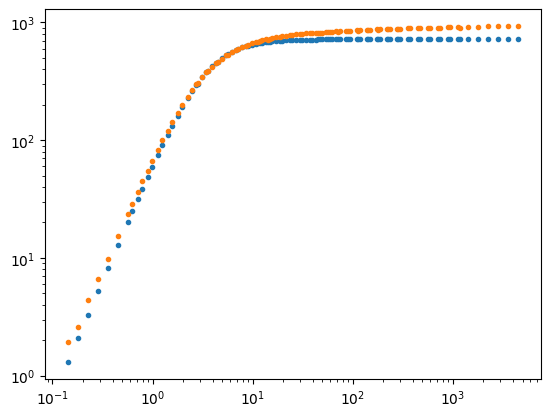

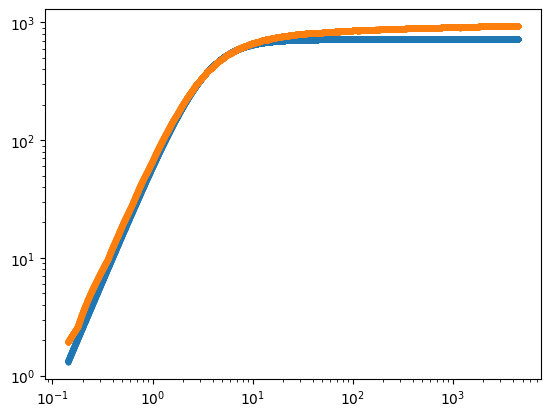

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8730940270435883
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9868940201619844
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8900508247015733
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9895740721408339
With same log spaced x range, mean absolute percentage error: 0.13860495566063727
With same log spaced x range, mean absolute log error: 0.1531138727086299
Integral mean absolute log error: 0.15204188269840976


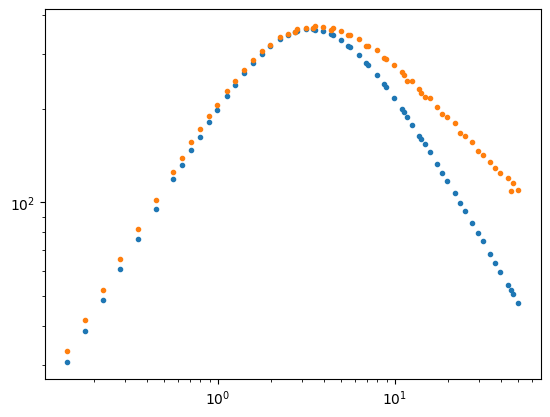

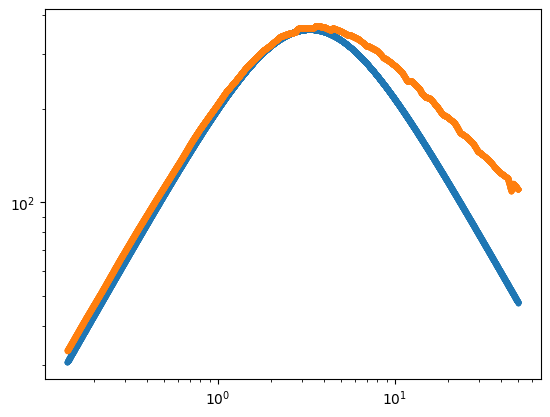

R² value between the two curves in the interval [5e-10, 50] is: 0.7878521303308827
R² value for log(y) values between the two curves in the interval [5e-10, 50] is: 0.594349617298362
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50] is: 0.8668313524229807
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50] is: 0.7969330434459221
With same log spaced x range, mean absolute percentage error: 0.1525651675706222
With same log spaced x range, mean absolute log error: 0.1885927918626635
Integral mean absolute log error: 0.1884839306735151


In [42]:
calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_storage_exp, x2=omega_t_sim1_shift_r1,y2=storage_mod_r1_shift,X_low=5* 10**-10,X_high=5* 10**10)

calc_r2_for_dyn_mod(x_ref=freq,y_ref=G_loss_exp, x2=omega_t_sim1_shift_r1,y2=loss_mod_r1_shift,X_low=5* 10**-10,X_high=5* 10**1)

# Comparison to exp data with different valency

In [34]:


#three arms
exp_data_dyn_mod_v3=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/3_arm_500uM_MasterCurve.dat",sep=",",header=None)
exp_data_dyn_mod_v3.columns=["freq.","G'","G''"]

freq_v3=exp_data_dyn_mod_v3["freq."].to_numpy()
G_storage_exp_v3=exp_data_dyn_mod_v3["G'"].to_numpy()
G_loss_exp_v3=exp_data_dyn_mod_v3["G''"].to_numpy()

#four arms
exp_data_dyn_mod_v4=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/FrequencySweep_4ArmDNAns_490uM.csv",sep=",",header=None)
exp_data_dyn_mod_v4.columns=["freq.","G'","G''"]

freq_v4=exp_data_dyn_mod_v4["freq."].to_numpy()
G_storage_exp_v4=exp_data_dyn_mod_v4["G'"].to_numpy()
G_loss_exp_v4=exp_data_dyn_mod_v4["G''"].to_numpy()

#five arms
exp_data_dyn_mod_v5=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/5_arm_490uM_MasterCurve(2).dat",sep=",",header=None)
exp_data_dyn_mod_v5.columns=["freq.","G'","G''"]

freq_v5=exp_data_dyn_mod_v5["freq."].to_numpy()
G_storage_exp_v5=exp_data_dyn_mod_v5["G'"].to_numpy()
G_loss_exp_v5=exp_data_dyn_mod_v5["G''"].to_numpy()

#six arms
exp_data_dyn_mod_v6=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_conrad_et_al/6_arm_450uM_MasterCurve.dat",sep=",",header=None)
exp_data_dyn_mod_v6.columns=["freq.","G'","G''"]

freq_v6=exp_data_dyn_mod_v6["freq."].to_numpy()
G_storage_exp_v6=exp_data_dyn_mod_v6["G'"].to_numpy()
G_loss_exp_v6=exp_data_dyn_mod_v6["G''"].to_numpy()

In [35]:
#three arms, Palombo et al 2025
exp_data_dyn_mod_v3b=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_palombo_et_al/2022.09.01_0.5mM_02_20C_FreqSweep.dat", delim_whitespace=True)


freq_v3b=exp_data_dyn_mod_v3b["Frequency(Hz)"].to_numpy()[::-1]
G_storage_exp_v3b=exp_data_dyn_mod_v3b["Shear_modulus_(elastic_component)(Pa)"].to_numpy()[::-1]
G_loss_exp_v3b=exp_data_dyn_mod_v3b["Shear_modulus_(viscous_component)(Pa)"].to_numpy()[::-1]


#the data is soparse around, need to interpolate to make reasonable predictions for cross over point
freq_v3b_os=np.geomspace(freq_v3b[0],freq_v3b[-1],10000)

G_storage_exp_v3b_os = np.interp(freq_v3b_os, freq_v3b, G_storage_exp_v3b)
G_loss_exp_v3b_os = np.interp(freq_v3b_os, freq_v3b, G_loss_exp_v3b)

/tmp/ipykernel_105/2524412780.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  exp_data_dyn_mod_v3b=pd.read_csv("/home/aaron/phd/Nanomotif_Coarse_Graining_1/ML_parameter_opt_1/NCG_X_motif_conrad_1/exp_data_palombo_et_al/2022.09.01_0.5mM_02_20C_FreqSweep.dat", delim_whitespace=True)


<Figure size 137.795x137.795 with 0 Axes>

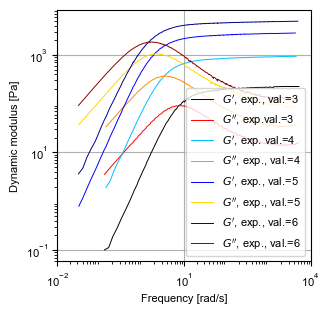

In [36]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, exp., val.=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, exp.val.=3",color="red",linewidth=0.7)

ax1.errorbar(freq_v4[::],G_storage_exp_v4[::],fmt="-",label=r"$G'$, exp. val.=4",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq_v4[::],G_loss_exp_v4[::],fmt="-",label=r"$G''$, exp., val.=4",color="darkorange",linewidth=0.7)

ax1.errorbar(freq_v5[::],G_storage_exp_v5[::],fmt="-",label=r"$G'$, exp., val.=5",color="blue",linewidth=0.7)
ax1.errorbar(freq_v5[::],G_loss_exp_v5[::],fmt="-",label=r"$G''$, exp., val.=5",color="gold",linewidth=0.7)

ax1.errorbar(freq_v6[::],G_storage_exp_v6[::],fmt="-",label=r"$G'$, exp., val.=6",color="darkblue",linewidth=0.7)
ax1.errorbar(freq_v6[::],G_loss_exp_v6[::],fmt="-",label=r"$G''$, exp., val.=6",color="darkred",linewidth=0.7)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**0,1500)
#plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

1200.0
1600.0
2000.0
2400.0
CPU times: user 21.8 s, sys: 35 s, total: 56.8 s
Wall time: 9.64 s


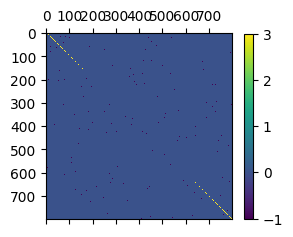

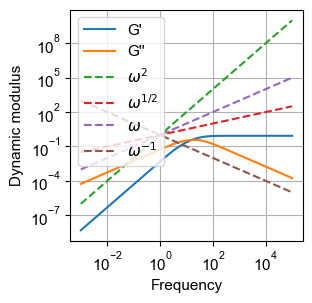

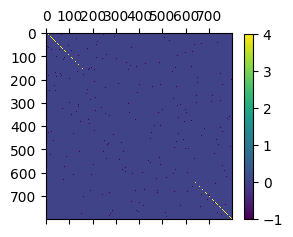

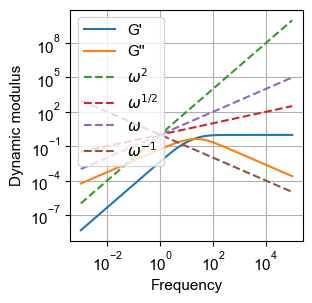

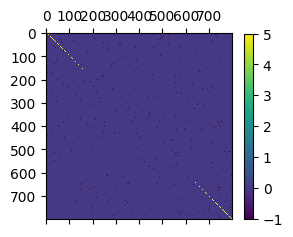

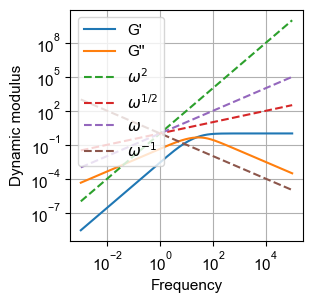

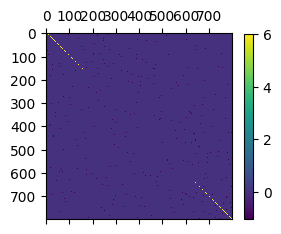

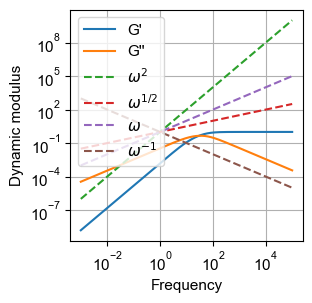

In [37]:
%%time
#generate theoretical graphs with matching valency and option to define max and min relax time
omega_t_sim1=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_sim1=np.geomspace(10**-2,10**3,10**2)
#number of nodes
num_nodes_list=[800,800,800,800]  #[800,800,800,800] #[100,100,100,100] #
#degree of each node
m_list=[3,4,5,6] #[3,4,5,6] 
#number of edges to add
p_list=[1200,1600,2000,2400] #[1200,1600,2000,2400]  #[150,200,250,300]   #
#random seed
rs_list=[1,1,1,1]

storage_mod_list_rd, loss_mod_list_rd, relaxation_mod_list_rd,relax_times_list_rd=theo_graph_gen(num_nodes_list,m_list,p_list,rs_list,omega_t_sim1,t_sim1,lim_to_one_relax_time=None,lower_t_lim=0,upper_t_lim=0.2)


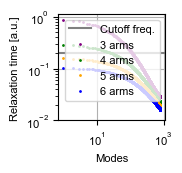

In [38]:
# relaxation times of graphs
#storage_mod_list_rd=[storage_mod_list_rd[3] for i in range(len(storage_mod_list_rd))] 
#loss_mod_list_rd=[loss_mod_list_rd[3] for i in range(len(loss_mod_list_rd))]

labels_relax_time_e=["3 arms","4 arms","5 arms","6 arms"]
colors_relax_times_e=["purple","green","orange","blue"]
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)
for i in range(len(relax_times_list_rd)):
    ax1.errorbar(np.arange(0,len(relax_times_list_rd[i])),relax_times_list_rd[i],fmt=".",label=labels_relax_time_e[i],markersize=2,color=colors_relax_times_e[i])
     #ax1.errorbar(np.arange(0,len(relax_times_list_rd[i])),relax_times_list_rd[i]*1/mult_factor_freq_rd_shift[i],fmt=".",label=labels_relax_time_e[i])
     #print(np.mean(1/(relax_times_list_rd[i]*1/mult_factor_freq_rd_shift[i])))
fs1=8
ax1.axhline(0.2,color="grey",label="Cutoff freq.")
#ax1.axhline(0.05)

'''color_cf1=["blue","orange","green","red"]
for i in range(len(cross_over_freq_exp)):
    ax1.axhline(1/cross_over_freq_exp[i],label=labels_relax_time_e[i],color=color_cf1[i])
'''
plt.xscale("log")
plt.yscale("log")
plt.grid()
#plt.ylim(10**-1,10**4)
#plt.xlim(10**-2,10**4)
plt.xticks([10**1,10**3],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-2,10**-1,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Relaxation time [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Modes",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="upper right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/relax_time_800nodes.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

R^2 for storage mod


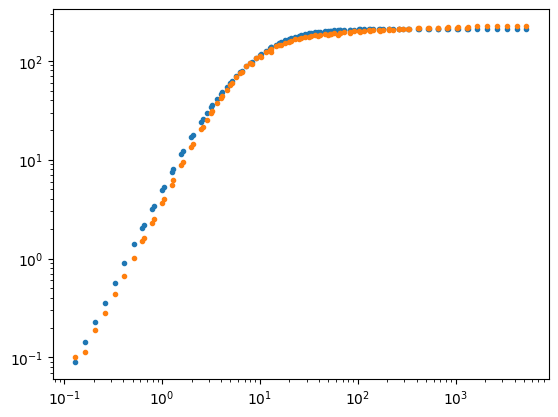

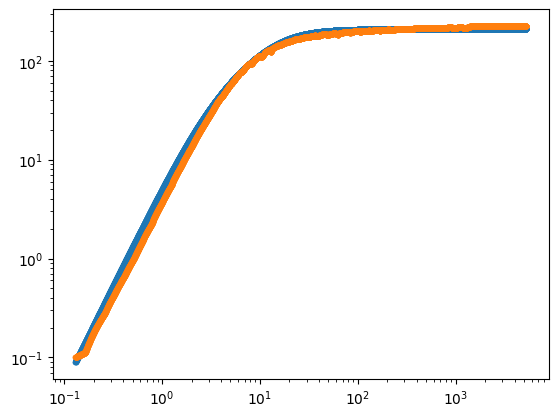

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.989532462102553
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9954264267108722
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9919485936542123
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9962404071361121
With same log spaced x range, mean absolute percentage error: 0.1167629945416845
With same log spaced x range, mean absolute log error: 0.10607953021076523
Integral mean absolute log error: 0.10755021587379995
R^2 for loss mod


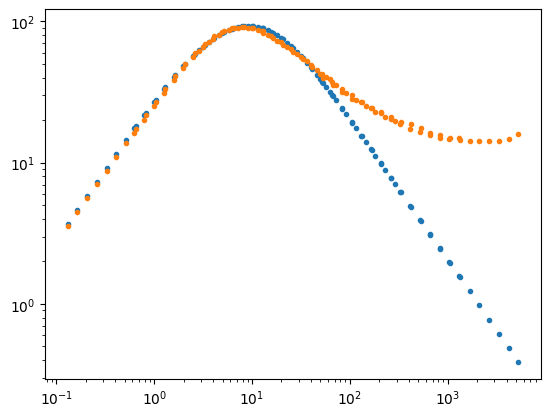

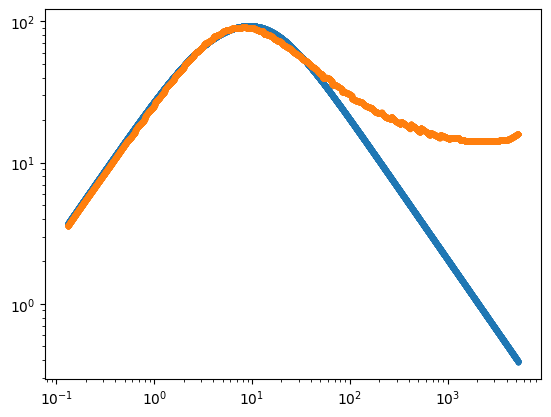

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9146915734759737
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.7969227249282713
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9013113265454193
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.4200887077903284
With same log spaced x range, mean absolute percentage error: 0.3218524544225184
With same log spaced x range, mean absolute log error: 0.720172356197331
Integral mean absolute log error: 0.7196906552180438
R^2 for storage mod


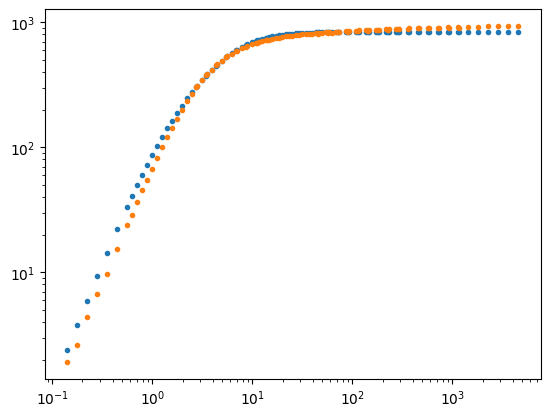

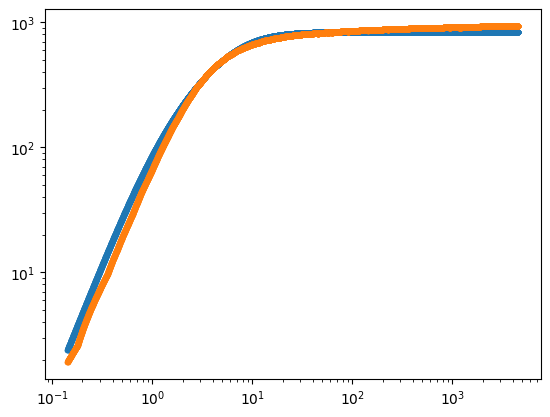

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9863259882136789
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.992066373033842
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9859910243598595
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.991949543358432
With same log spaced x range, mean absolute percentage error: 0.11735838363652487
With same log spaced x range, mean absolute log error: 0.10610322430041624
Integral mean absolute log error: 0.1071944884109254
R^2 for loss mod


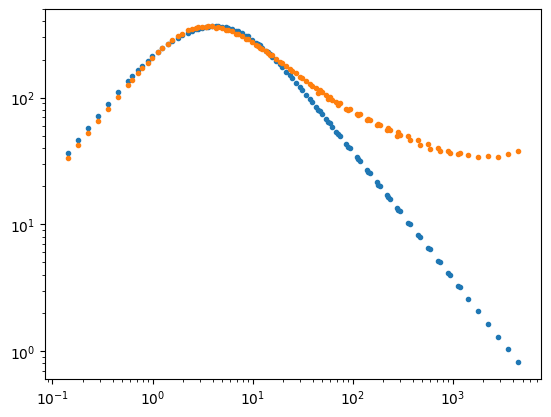

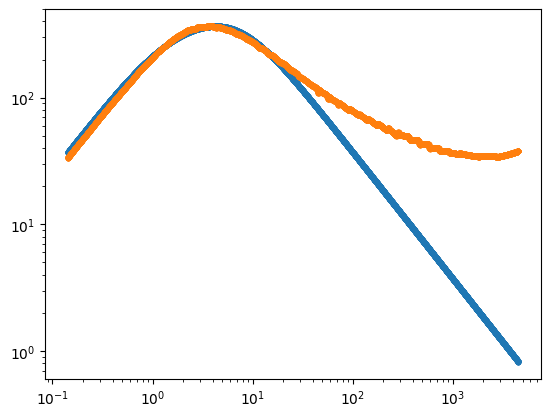

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9426932683546735
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -0.9969790283582067
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9441763472038096
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.7768418045366996
With same log spaced x range, mean absolute percentage error: 0.3735849680252518
With same log spaced x range, mean absolute log error: 0.8445155725775371
Integral mean absolute log error: 0.8441675198880368
R^2 for storage mod


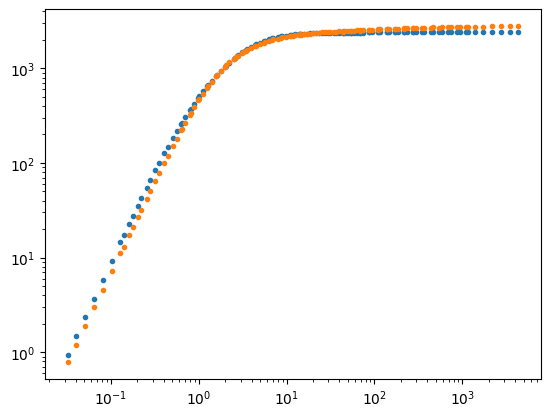

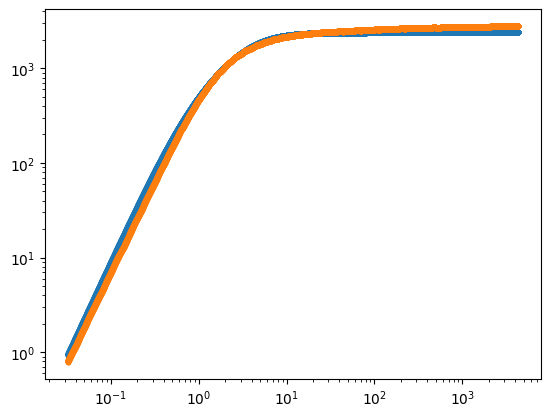

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9749547196235122
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9959190003351374
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9727497762182413
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9964399486879292
With same log spaced x range, mean absolute percentage error: 0.11829956016736629
With same log spaced x range, mean absolute log error: 0.11285325377480199
Integral mean absolute log error: 0.11405889045222531
R^2 for loss mod


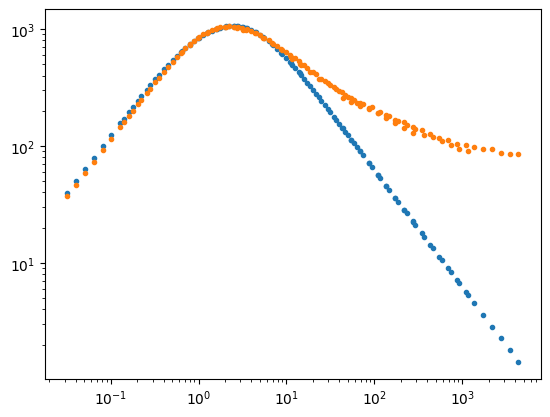

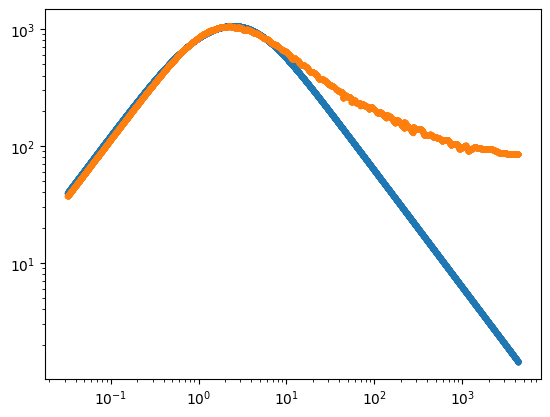

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9267454363706894
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.157944613445546
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9312065533131836
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.7873051757607081
With same log spaced x range, mean absolute percentage error: 0.38605055294540586
With same log spaced x range, mean absolute log error: 0.9392846499938629
Integral mean absolute log error: 0.9387854309148329
R^2 for storage mod


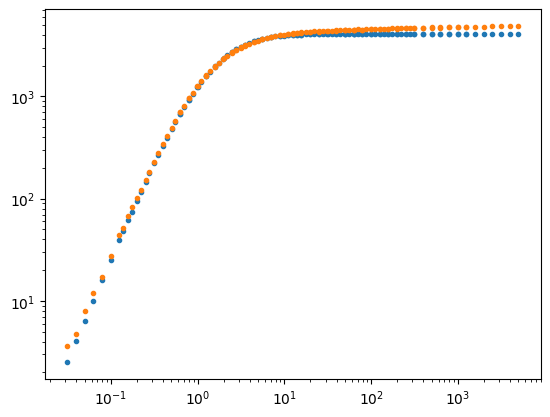

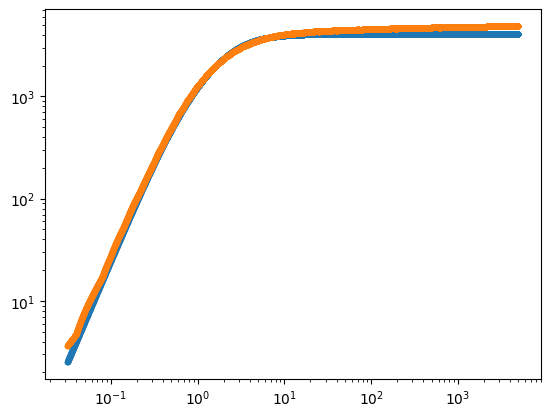

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9548847616188533
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.996334655754158
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9562291849099158
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9969428674276808
With same log spaced x range, mean absolute percentage error: 0.08659854755485596
With same log spaced x range, mean absolute log error: 0.09260949926265288
Integral mean absolute log error: 0.0915762260343426
R^2 for loss mod


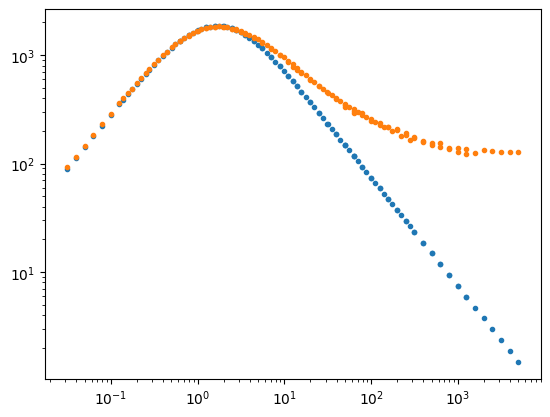

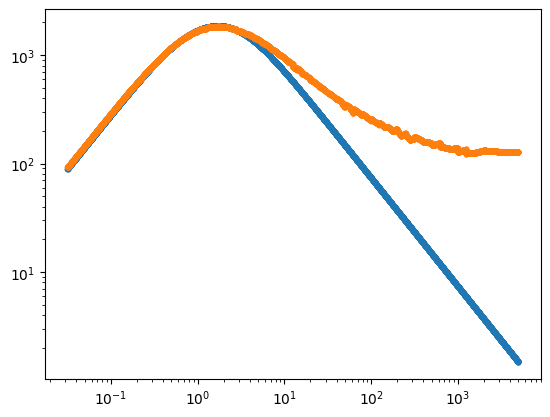

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.939718422786641
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.166899297031832
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9445293943797209
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.0096468932643528
With same log spaced x range, mean absolute percentage error: 0.40550857984051797
With same log spaced x range, mean absolute log error: 1.0323609004991217
Integral mean absolute log error: 1.0319084471869957


In [40]:
# evaluate similarity of prediction to exp data
storage_mod_exp_list=[G_storage_exp_v3,G_storage_exp_v4,G_storage_exp_v5,G_storage_exp_v6]
loss_mod_exp_list=[G_loss_exp_v3,G_loss_exp_v4,G_loss_exp_v5,G_loss_exp_v6]
freq_list=[freq_v3,freq_v4,freq_v5,freq_v6]

omega_t_list_rd=[omega_t_sim1 for e in range(len(storage_mod_list_rd))]

storage_mod_list_rd_shift, loss_mod_list_rd_shift, omega_t_list_rd_shift,cross_over_freq_exp,cross_over_mod_exp,mult_factor_freq_rd_shift=shift_mod(storage_mod_list=storage_mod_list_rd,loss_mod_list=loss_mod_list_rd,omega_t_list=omega_t_list_rd,  storage_mod_exp_list=storage_mod_exp_list,loss_mod_exp_list=loss_mod_exp_list,freq_list=freq_list)

R^2 for storage mod


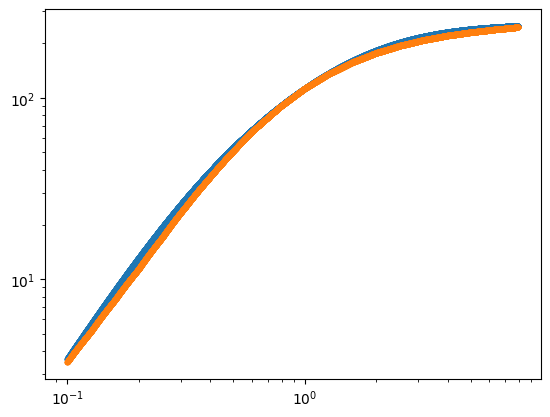

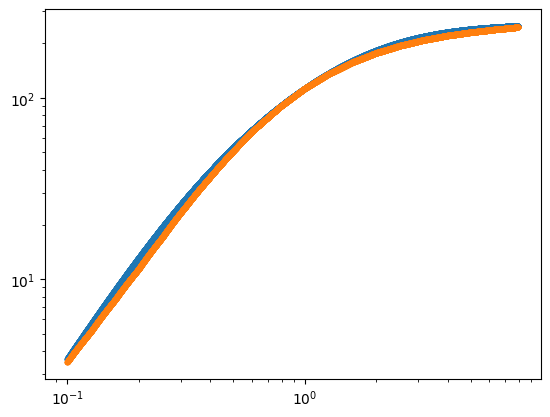

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9965303911559241
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.997445122012949
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9965303911559241
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.997445122012949
With same log spaced x range, mean absolute percentage error: 0.05478601831941426
With same log spaced x range, mean absolute log error: 0.05256201617792531
Integral mean absolute log error: 0.0525544192264234
R^2 for loss mod


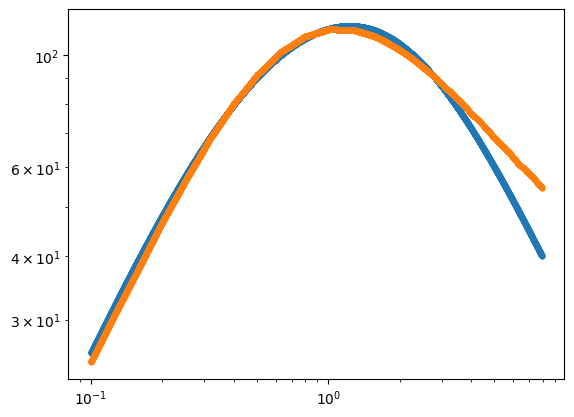

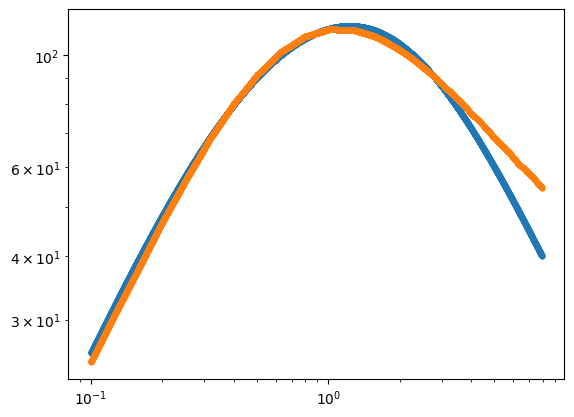

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9706611162620672
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9607585301616532
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9706611162620672
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9607585301616532
With same log spaced x range, mean absolute percentage error: 0.04366025455197142
With same log spaced x range, mean absolute log error: 0.046236378287285815
Integral mean absolute log error: 0.046231004815948794


In [41]:
storage_mod_list_rd_shift_mr, loss_mod_list_rd_shift_mr, omega_t_list_rd_shift_mr,cross_over_freq_exp_mr,cross_over_mod_exp_mr,mult_factor_freq_rd_shift_mr=shift_mod(storage_mod_list=[storage_mod_list_rd[0]],loss_mod_list=[loss_mod_list_rd[0]],omega_t_list=[omega_t_list_rd[0]],  storage_mod_exp_list=[G_storage_exp_v3b_os],loss_mod_exp_list=[G_loss_exp_v3b_os],freq_list=[freq_v3b_os])

R^2 for storage mod


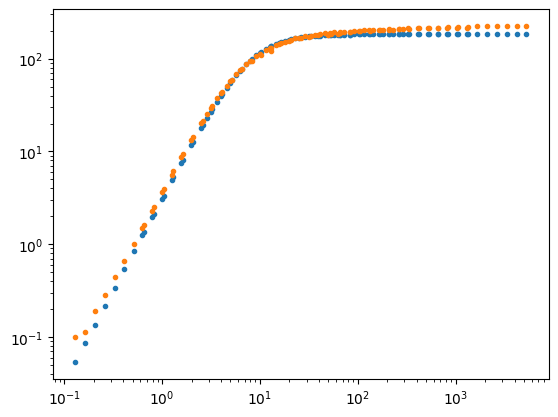

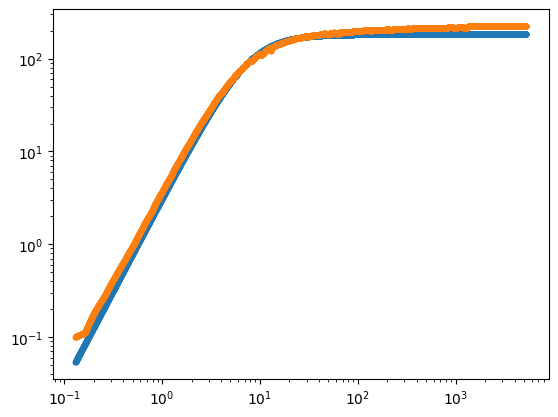

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9530667784162289
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9947011202498591
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9496854632326125
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9950769084444018
With same log spaced x range, mean absolute percentage error: 0.12410780420992829
With same log spaced x range, mean absolute log error: 0.1365937582072981
Integral mean absolute log error: 0.13510824988627698
R^2 for loss mod


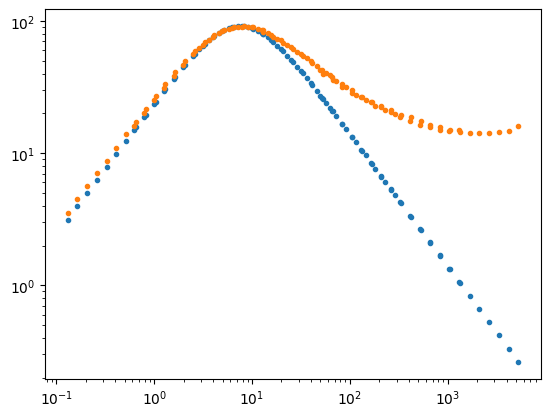

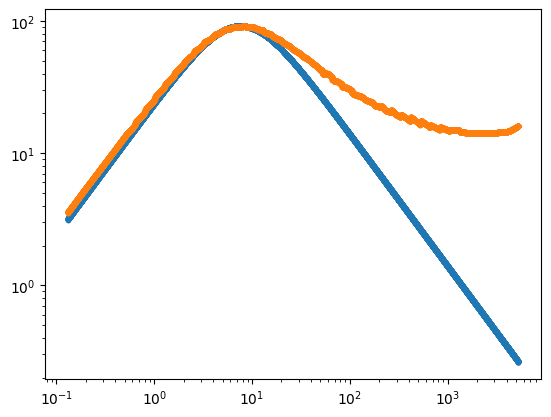

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8329302993289732
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.6422851766036493
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8371212382636899
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.3615176346753466
With same log spaced x range, mean absolute percentage error: 0.3954298906282392
With same log spaced x range, mean absolute log error: 0.9240748482296556
Integral mean absolute log error: 0.9236764541323016
R^2 for storage mod


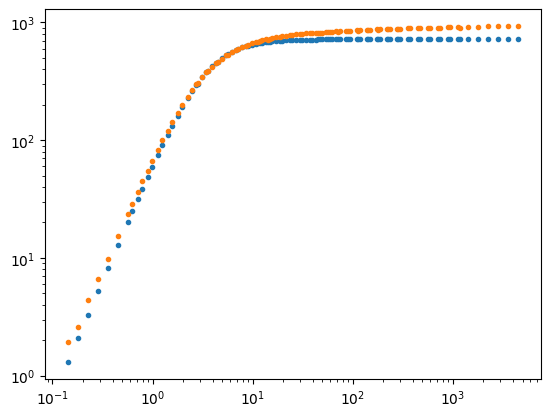

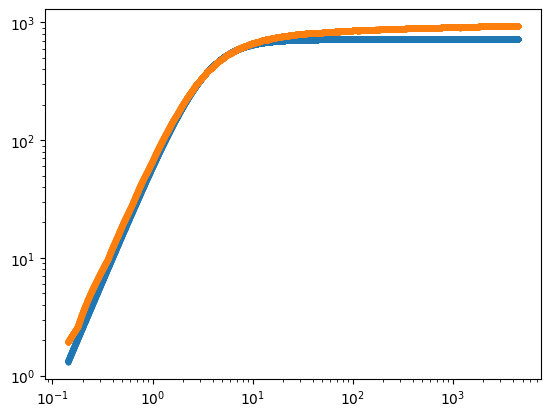

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8730940270435883
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9868940201619844
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8900508247015733
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9895740721408339
With same log spaced x range, mean absolute percentage error: 0.13860495566063727
With same log spaced x range, mean absolute log error: 0.1531138727086299
Integral mean absolute log error: 0.15204188269840976
R^2 for loss mod


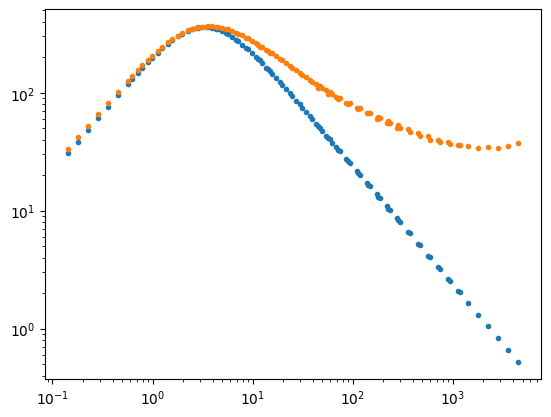

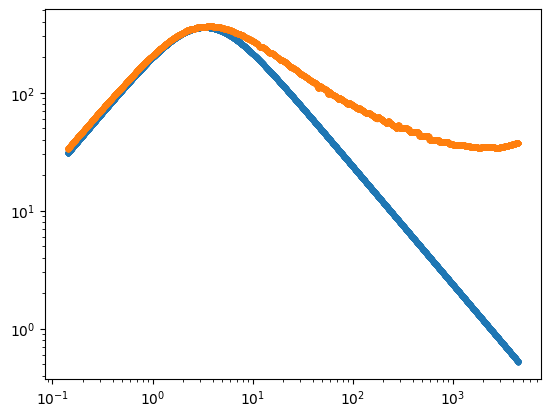

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8359570582696105
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.102501317457711
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8656702820791219
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -3.0163514718591786
With same log spaced x range, mean absolute percentage error: 0.45525857474456005
With same log spaced x range, mean absolute log error: 1.10227165170577
Integral mean absolute log error: 1.1019080148188378
R^2 for storage mod


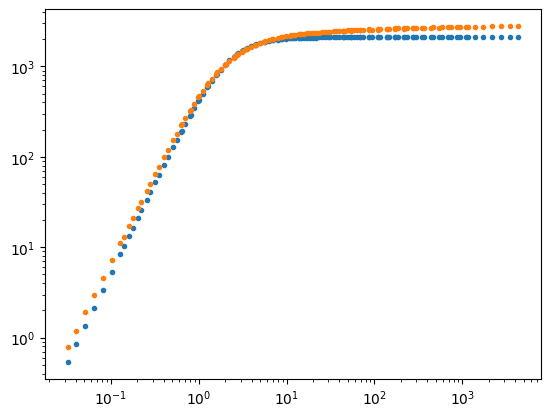

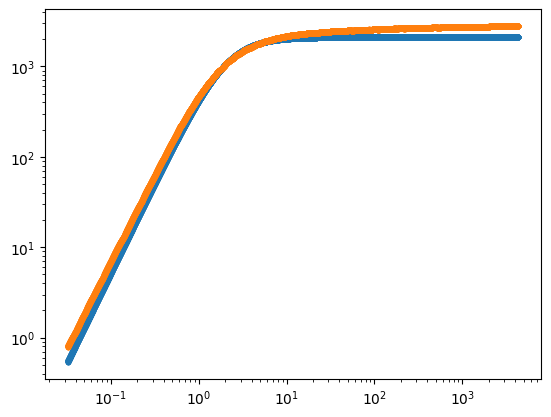

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8847400399074957
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9906124809278112
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8908905990964009
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.992070173889056
With same log spaced x range, mean absolute percentage error: 0.16486693536732427
With same log spaced x range, mean absolute log error: 0.18506655105034253
Integral mean absolute log error: 0.18386176890387793
R^2 for loss mod


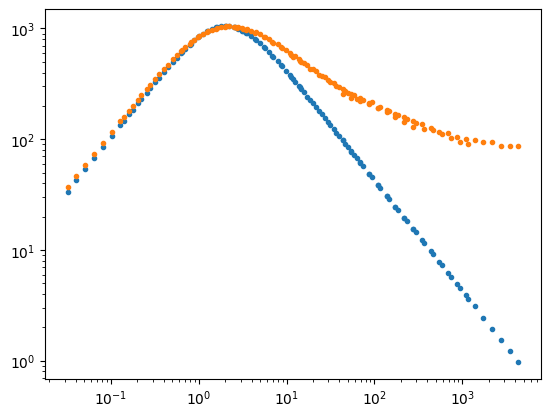

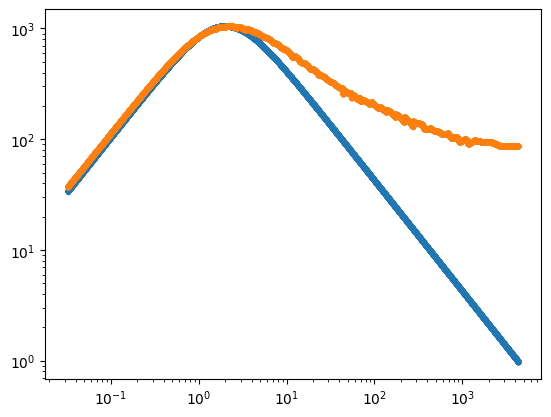

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8367378767050497
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.0213737906461358
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8588201091898461
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.700111130856254
With same log spaced x range, mean absolute percentage error: 0.44946290928481003
With same log spaced x range, mean absolute log error: 1.1521999870087538
Integral mean absolute log error: 1.1516913628223262
R^2 for storage mod


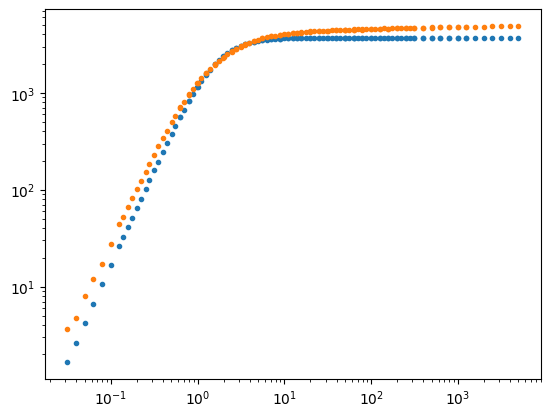

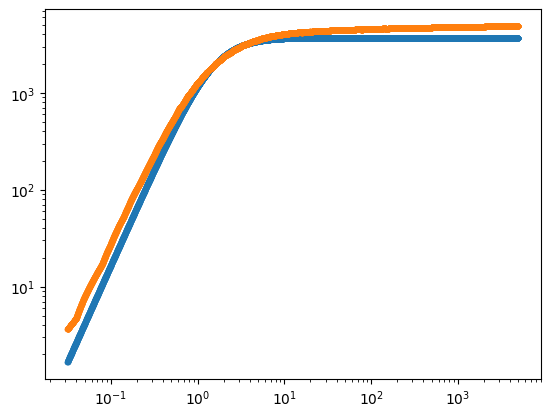

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8665174856139397
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9771979358157836
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8816661644290312
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9795716749403185
With same log spaced x range, mean absolute percentage error: 0.20409169045204514
With same log spaced x range, mean absolute log error: 0.24116166939565628
Integral mean absolute log error: 0.24013828244712346
R^2 for loss mod


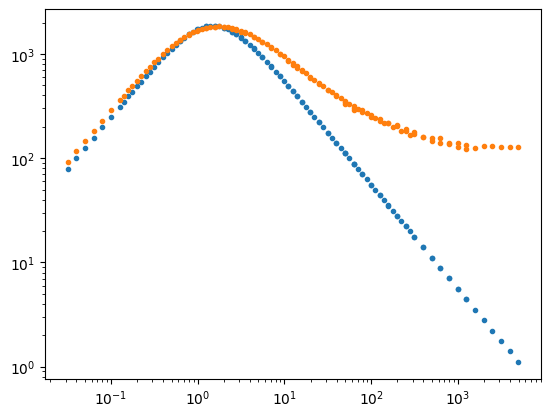

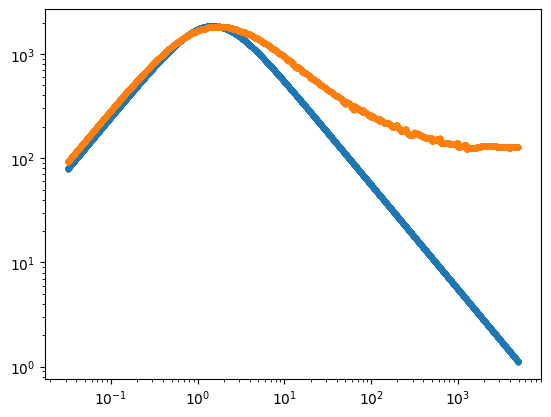

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8693957922609893
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -1.7799182092816999
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.8858531307292102
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: -2.7050002175033727
With same log spaced x range, mean absolute percentage error: 0.47960389029344935
With same log spaced x range, mean absolute log error: 1.2285739306731507
Integral mean absolute log error: 1.2281069960742035


In [42]:
storage_mod_exp_list=[G_storage_exp_v3,G_storage_exp_v4,G_storage_exp_v5,G_storage_exp_v6]
loss_mod_exp_list=[G_loss_exp_v3,G_loss_exp_v4,G_loss_exp_v5,G_loss_exp_v6]
freq_list=[freq_v3,freq_v4,freq_v5,freq_v6]

storage_mod_1relt_list=[storage_mod_r1 for e in range(len(storage_mod_exp_list))]
loss_mod_1relt_list=[loss_mod_r1 for e in range(len(storage_mod_exp_list))]

omega_t_list_rd=[omega_t_sim1 for e in range(len(storage_mod_exp_list))]

storage_mod_list_1relt_shift, loss_mod_list_1relt_shift, omega_t_list_1relt_shift,cross_over_freq_exp,cross_over_mod_exp,mult_factor_freq_1relt_shift=shift_mod(storage_mod_list=storage_mod_1relt_list,loss_mod_list=loss_mod_1relt_list,omega_t_list=omega_t_list_rd,  storage_mod_exp_list=storage_mod_exp_list,loss_mod_exp_list=loss_mod_exp_list,freq_list=freq_list)

R^2 for storage mod


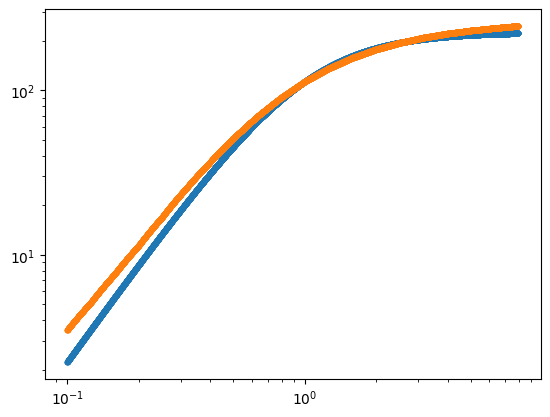

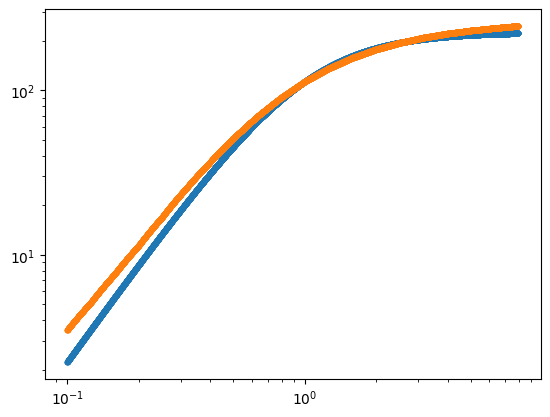

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9923061544859288
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9811471005145166
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.9923061544859288
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.9811471005145166
With same log spaced x range, mean absolute percentage error: 0.11119907162301693
With same log spaced x range, mean absolute log error: 0.1254332192603965
Integral mean absolute log error: 0.12543784701757496
R^2 for loss mod


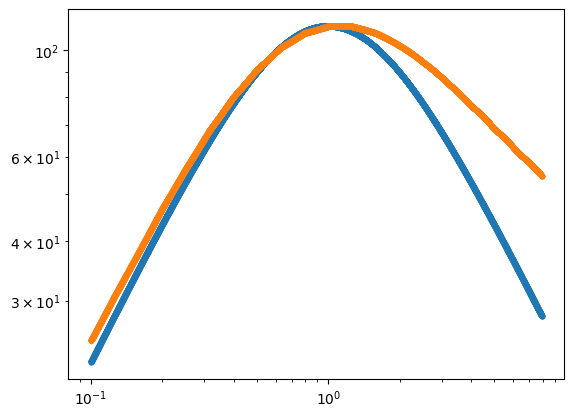

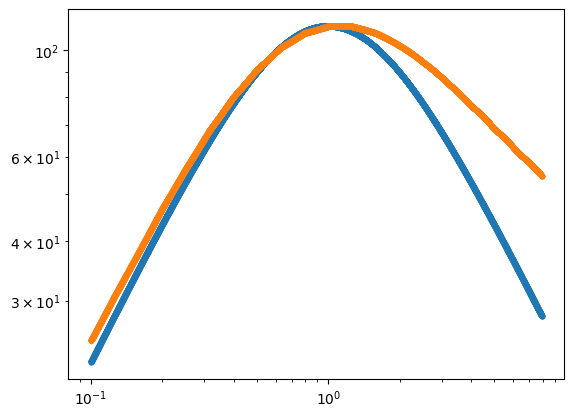

R² value between the two curves in the interval [5e-10, 50000000000] is: 0.7486693891434434
R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.6572046666810505
With same log spaced x range, R² value between the two curves in the interval [5e-10, 50000000000] is: 0.7486693891434434
With same log spaced x range, R² value for log(y) values between the two curves in the interval [5e-10, 50000000000] is: 0.6572046666810505
With same log spaced x range, mean absolute percentage error: 0.12864897460117586
With same log spaced x range, mean absolute log error: 0.1528542106877175
Integral mean absolute log error: 0.15284621359183193


In [43]:
storage_mod_list_1relt_shift_mr, loss_mod_list_1relt_shift_mr, omega_t_list_1relt_shift_mr,cross_over_freq_exp_mr,cross_over_mod_exp_mr,mult_factor_freq_1relt_shift_mr=shift_mod(storage_mod_list=[storage_mod_1relt_list[0]],loss_mod_list=[loss_mod_1relt_list[0]],omega_t_list=[omega_t_list_rd[0]],  storage_mod_exp_list=[G_storage_exp_v3b_os],loss_mod_exp_list=[G_loss_exp_v3b_os],freq_list=[freq_v3b_os])

<Figure size 137.795x137.795 with 0 Axes>

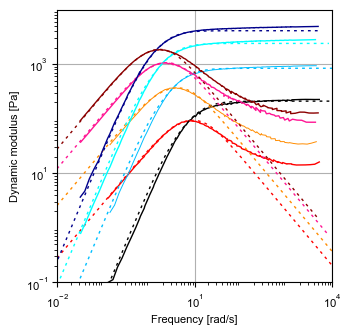

In [47]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, degree=3",color="black",linewidth=1)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, degree=3",color="red",linewidth=1)

line1=ax1.errorbar(omega_t_list_rd_shift[0][::],storage_mod_list_rd_shift[0][::],fmt=":",label=r"$G'$ sim.",color="black",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[0][::],loss_mod_list_rd_shift[0][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="red",linewidth=1)
line2[0].set_dashes([2,3]) 


ax1.errorbar(freq_v4[::],G_storage_exp_v4[::],fmt="-",label=r"$G'$, degree=4",color="deepskyblue",linewidth=0.7)
ax1.errorbar(freq_v4[::],G_loss_exp_v4[::],fmt="-",label=r"$G''$, degree=4",color="darkorange",linewidth=0.7)

line1=ax1.errorbar(omega_t_list_rd_shift[1][::],storage_mod_list_rd_shift[1][::],fmt=":",label=r"$G'$ sim.",color="deepskyblue",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[1][::],loss_mod_list_rd_shift[1][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="darkorange",linewidth=1)
line2[0].set_dashes([2,3]) 



ax1.errorbar(freq_v5[::],G_storage_exp_v5[::],fmt="-",label=r"$G'$, exp., val.=5",color="cyan",linewidth=1)
ax1.errorbar(freq_v5[::],G_loss_exp_v5[::],fmt="-",label=r"$G''$, exp., val.=5",color="deeppink",linewidth=1)

line1=ax1.errorbar(omega_t_list_rd_shift[2][::],storage_mod_list_rd_shift[2][::],fmt=":",label=r"$G'$ sim.",color="cyan",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[2][::],loss_mod_list_rd_shift[2][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="deeppink",linewidth=1)
line2[0].set_dashes([2,3]) 


ax1.errorbar(freq_v6[::],G_storage_exp_v6[::],fmt="-",label=r"$G'$, degree=6",color="darkblue",linewidth=1)
ax1.errorbar(freq_v6[::],G_loss_exp_v6[::],fmt="-",label=r"$G''$, degree=6",color="darkred",linewidth=1)

line1=ax1.errorbar(omega_t_list_rd_shift[3][::],storage_mod_list_rd_shift[3][::],fmt=":",label=r"$G'$ sim.",color="darkblue",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[3][::],loss_mod_list_rd_shift[3][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="darkred",linewidth=1)
line2[0].set_dashes([2, 3]) 

#plt.axvline(0.28)
#plt.axhline(21.15)

#plt.axvline(10.56)
#plt.axhline(0.38)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**-1,10**4)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_valency_lim_freq_1.pdf"
#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_all_valency6_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

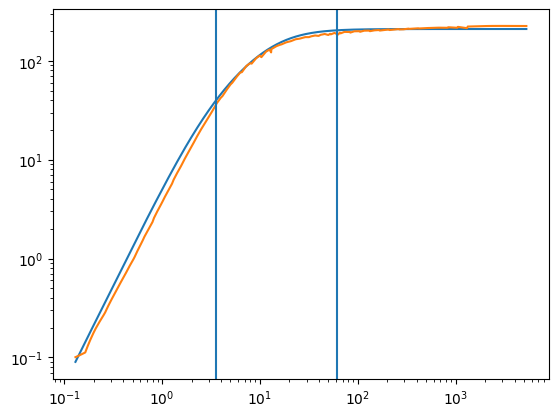

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (3.5899641478090873, 61.961610636484295)


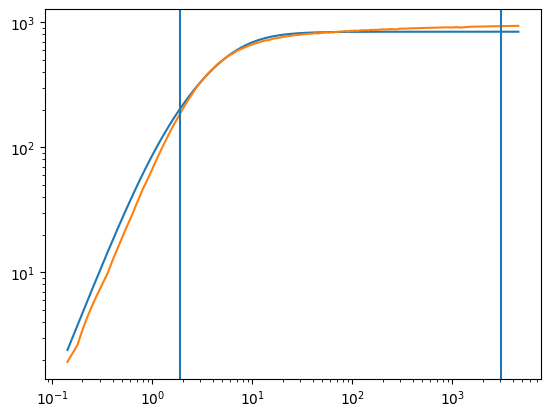

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (1.8662992217275014, 3085.7687531472448)


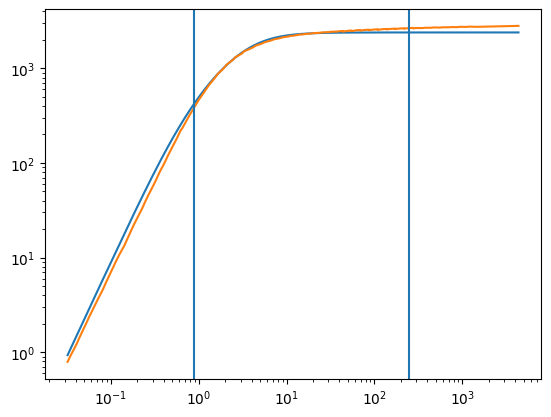

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (0.8859037757981066, 244.58354605482282)


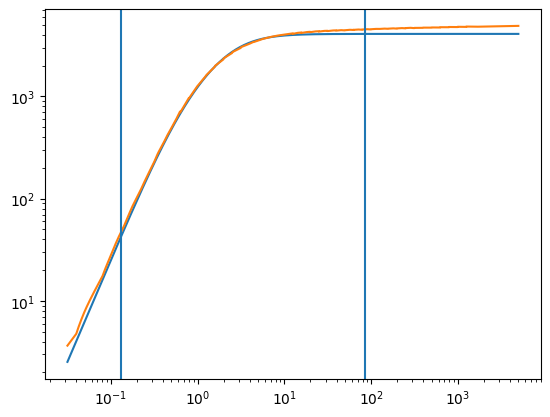

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.12999287644264917, 85.98339031278203)


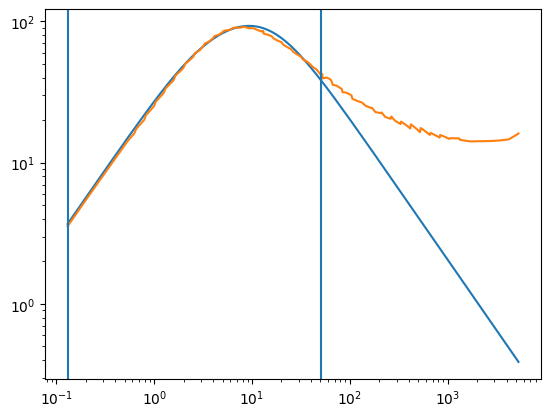

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (0.130258, 50.91641112587363)


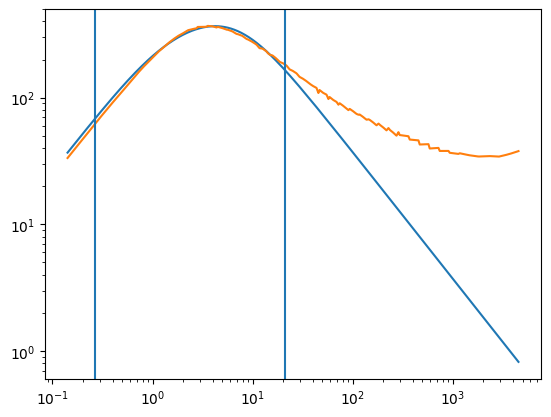

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (0.26347568041294533, 21.26650740315708)


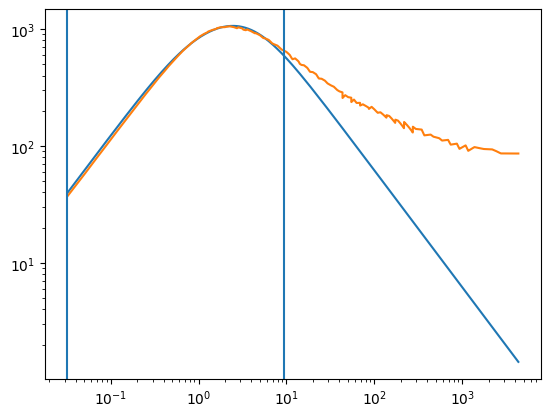

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (0.0322719, 9.507851230071555)


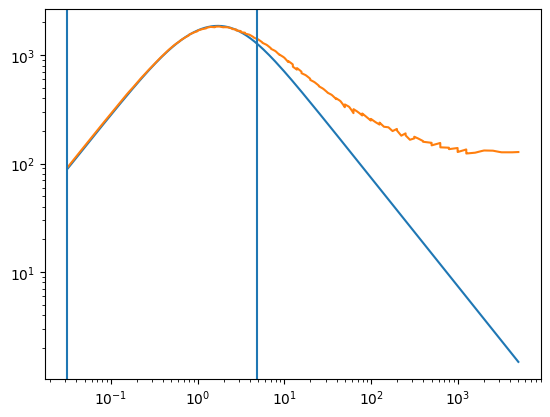

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.0316623, 4.903504865141543)


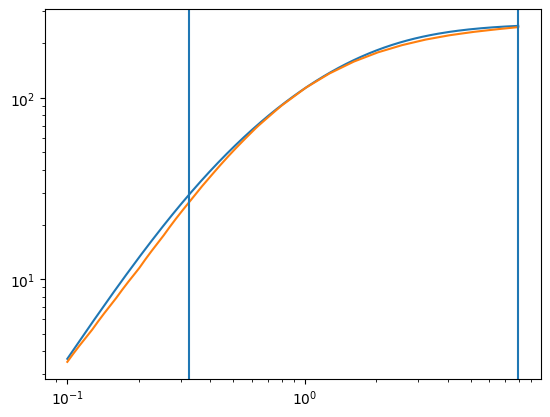

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.3255870341727476, 7.943)


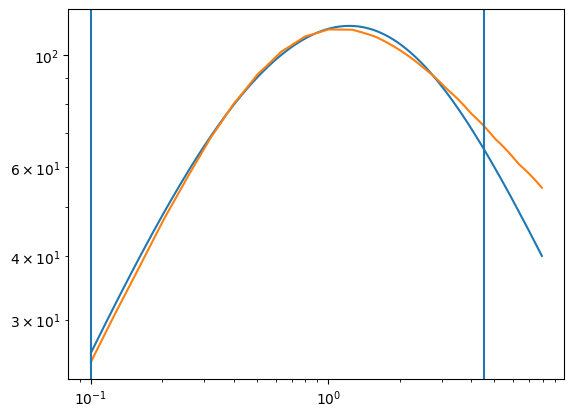

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.1, 4.525036759278488)


In [45]:
# generate cofidence regions around cross over freq.
conf_region_storage_theo=[region_of_conf(x_ref=freq_list[e],y_ref=storage_mod_exp_list[e], x2=omega_t_list_rd_shift[e],y2=storage_mod_list_rd_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0],n_false_allowed=10 ) for e in [0,1,2,3]]
conf_region_loss_theo=[region_of_conf(x_ref=freq_list[e],y_ref=loss_mod_exp_list[e], x2=omega_t_list_rd_shift[e],y2=loss_mod_list_rd_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0] ,n_false_allowed=10) for e in [0,1,2,3]]

conf_region_storage_theo_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_storage_exp_v3b_os, x2=omega_t_list_rd_shift_mr[0],y2=storage_mod_list_rd_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0],n_false_allowed=10 )]
conf_region_loss_theo_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_loss_exp_v3b_os, x2=omega_t_list_rd_shift_mr[0],y2=loss_mod_list_rd_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0] ,n_false_allowed=10)]


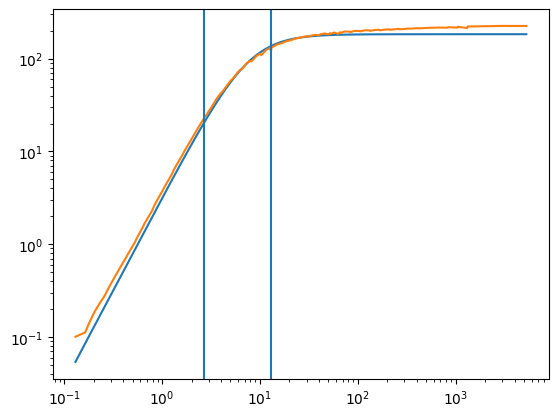

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (2.69842478908463, 12.88259601860398)


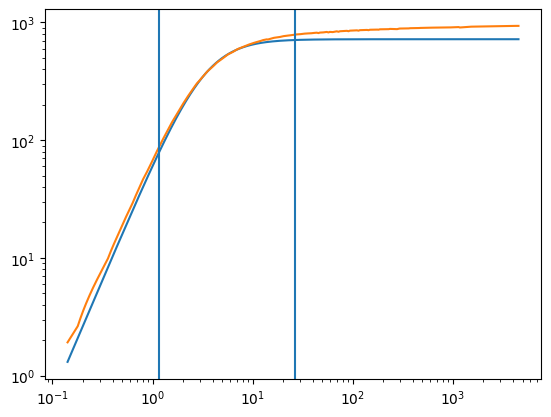

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (1.1698054867583845, 26.61170065973444)


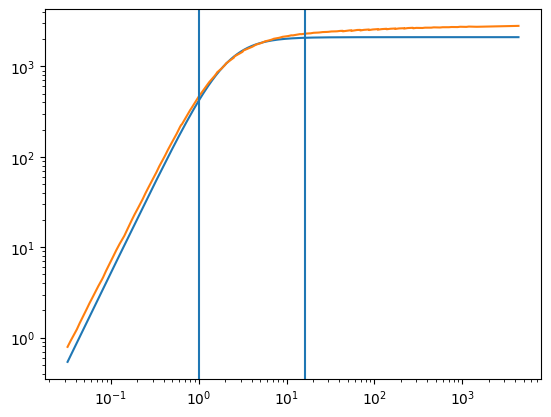

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (1.0076456384452623, 16.409921543470226)


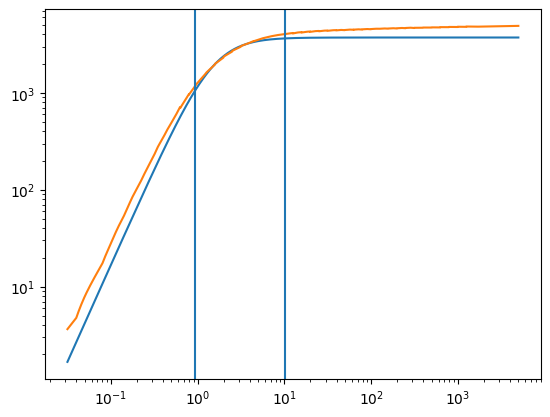

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.9457282287861851, 10.261953851665512)


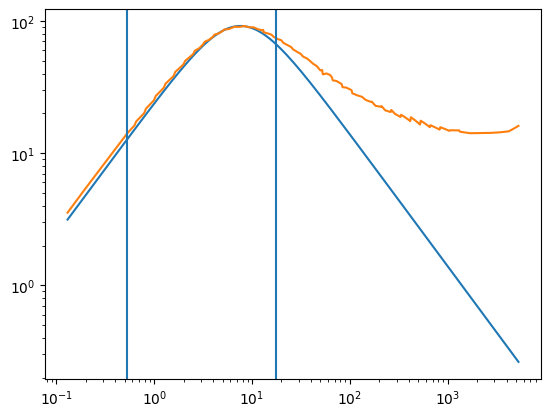

Longest contiguous x-range where deviation is less than 10% and includes 7.58082: (0.5241963062461624, 17.581040560160314)


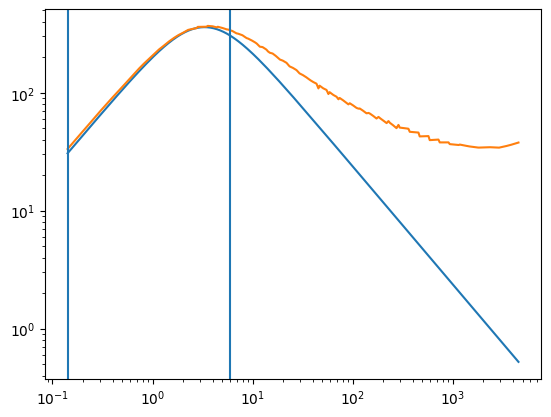

Longest contiguous x-range where deviation is less than 10% and includes 3.30506: (0.141482, 5.987543663059072)


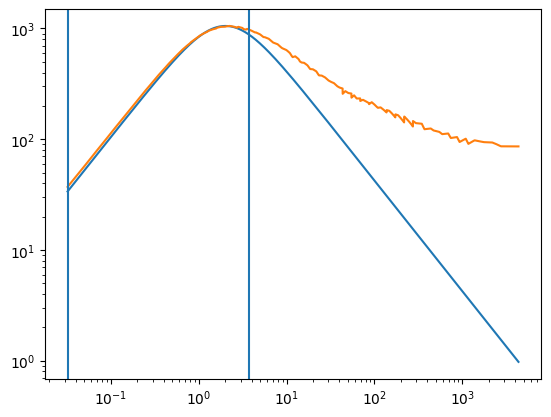

Longest contiguous x-range where deviation is less than 10% and includes 2.01155: (0.0322719, 3.7613745130740117)


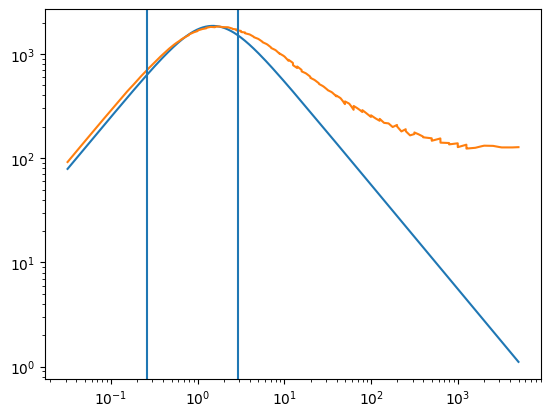

Longest contiguous x-range where deviation is less than 10% and includes 1.48807: (0.26213732090951286, 2.899409376254754)


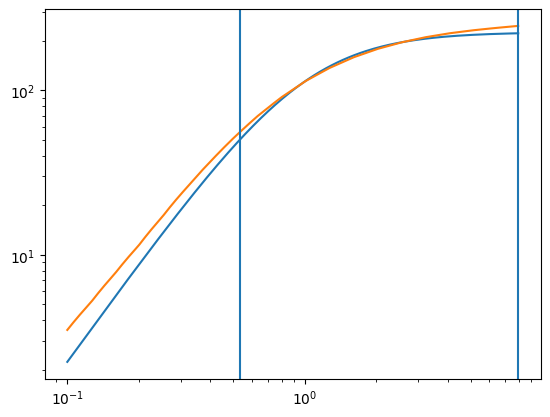

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.5352133454796361, 7.943)


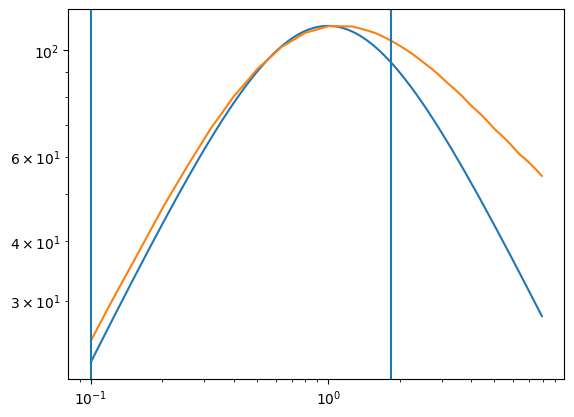

Longest contiguous x-range where deviation is less than 10% and includes 0.995558325449778: (0.1, 1.8429615318637929)


In [46]:
conf_region_storage_1relt=[region_of_conf(x_ref=freq_list[e],y_ref=storage_mod_exp_list[e], x2=omega_t_list_1relt_shift[e],y2=storage_mod_list_1relt_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0],n_false_allowed=10 ) for e in [0,1,2,3]]
conf_region_loss_1relt=[region_of_conf(x_ref=freq_list[e],y_ref=loss_mod_exp_list[e], x2=omega_t_list_1relt_shift[e],y2=loss_mod_list_1relt_shift[e],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_list[e], y1=storage_mod_exp_list[e], x2=freq_list[e], y2=loss_mod_exp_list[e])[0][0],n_false_allowed=10 ) for e in [0,1,2,3]]


conf_region_storage_1relt_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_storage_exp_v3b_os, x2=omega_t_list_1relt_shift_mr[0],y2=storage_mod_list_1relt_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0],n_false_allowed=10 )]
conf_region_loss_1relt_mr=[region_of_conf(x_ref=freq_v3b_os,y_ref=G_loss_exp_v3b_os, x2=omega_t_list_1relt_shift_mr[0],y2=loss_mod_list_1relt_shift_mr[0],X_low=5*10**-10,X_high=5*10**10,dev_p=10,x_t=find_intersection(x1=freq_v3b_os, y1=G_storage_exp_v3b_os, x2=freq_v3b_os, y2=G_loss_exp_v3b_os)[0][0],n_false_allowed=10 )]


<Figure size 137.795x137.795 with 0 Axes>

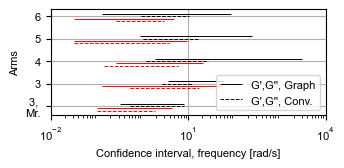

In [64]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
fig=plt.figure(figsize=(9/2.54,3.5/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)

for i in range(len(conf_region_storage_theo)):
    r1,r2=conf_region_storage_theo[i][0]
    k1,k2=conf_region_storage_1relt[i][0]
    ax1.hlines(i+0.1,r1,r2,color="black",linewidth=0.7)
    ax1.hlines(i-0.1+0.1,k1,k2,color="black",linestyles="--",linewidth=0.7)

    r1,r2=conf_region_loss_theo[i][0]
    k1,k2=conf_region_loss_1relt[i][0]
    ax1.hlines(i-0.1,r1,r2,color="red",linewidth=0.7)
    ax1.hlines(i-0.1-0.1,k1,k2,color="red",linestyles="--",linewidth=0.7)

r1,r2=conf_region_storage_theo_mr[0][0]
k1,k2=conf_region_storage_1relt_mr[0][0]
ax1.hlines(-1+0.1,r1,r2,color="black",linewidth=0.7,label="G',G'', Graph")
ax1.hlines(-1-0.1+0.1,k1,k2,color="black",linestyles="--",linewidth=0.7,label="G',G'', Conv.")

r1,r2=conf_region_loss_theo_mr[0][0]
k1,k2=conf_region_loss_1relt_mr[0][0]
ax1.hlines(-1-0.1,r1,r2,color="red",linewidth=0.7)
ax1.hlines(-1-0.1-0.1,k1,k2,color="red",linestyles="--",linewidth=0.7)
    
fs1=8
plt.xscale("log")
#plt.yscale("log")
plt.grid()
#plt.ylim(10**-1,10**4)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([-1,0,1,2,3],["3, \nMr.","3","4","5","6"],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Arms",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Confidence interval, frequency [rad/s]",fontname = "Arial",fontsize=fs1)
ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/confidence_interval_lim_freq_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

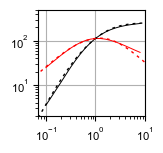

In [65]:
fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
#fig=plt.figure(figsize=(8.3/2.54,8.3/2.54))

ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3b[::],G_storage_exp_v3b[::],fmt="-",label=r"$G'$, degree=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3b[::],G_loss_exp_v3b[::],fmt="-",label=r"$G''$, degree=3",color="red",linewidth=0.7)

line1=ax1.errorbar(omega_t_list_rd_shift_mr[0][::],storage_mod_list_rd_shift_mr[0][::],fmt="-",label=r"$G'$ sim.",color="black",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift_mr[0][::],loss_mod_list_rd_shift_mr[0][::],fmt="-",label=r"$G''-\omega \eta$ sim.",color="red",linewidth=1)
line2[0].set_dashes([2,3]) 


#plt.axvline(0.28)
#plt.axhline(21.15)

#plt.axvline(10.56)
#plt.axhline(0.38)

fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(2,500)
plt.xlim(7*10**-2,10**1)
plt.xticks([10**-1,10**0,10**1],fontname = "Arial",fontsize=fs1)
plt.yticks([10**1,10**2],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
#ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
#ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_MR_lim_freq_1.pdf"
#save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_theo_valency6_MR_1.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

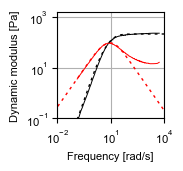

In [66]:

#for i in range(len(storage_mod_exp_list)):

fig=plt.figure(figsize=(3.5/2.54,3.5/2.54))
#ax1 = fig.add_subplot(111)
#fig=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig.add_subplot(111)

ax1.errorbar(freq_v3[::],G_storage_exp_v3[::],fmt="-",label=r"$G'$, degree=3",color="black",linewidth=0.7)
ax1.errorbar(freq_v3[::],G_loss_exp_v3[::],fmt="-",label=r"$G''$, degree=3",color="red",linewidth=0.7)

line1=ax1.errorbar(omega_t_list_rd_shift[0][::],storage_mod_list_rd_shift[0][::],fmt=":",label=r"$G'$ sim.",color="black",linewidth=1)
line1[0].set_dashes([2,3])  

line2=ax1.errorbar(omega_t_list_rd_shift[0][::],loss_mod_list_rd_shift[0][::],fmt=":",label=r"$G''-\omega \eta$ sim.",color="red",linewidth=1)
line2[0].set_dashes([2,3]) 

    
fs1=8
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.ylim(10**0,1500)
plt.xlim(10**-2,10**4)
plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
plt.yticks([10**-1,10**1,10**3],fontname = "Arial",fontsize=fs1)
#plt.xticks([10**-2,10**0,10**2],fontname = "Arial",fontsize=fs1)
#plt.yticks([10**-6,10**-4,10**-2,10**0],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Dynamic modulus [Pa]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Frequency [rad/s]",fontname = "Arial",fontsize=fs1)
#ax1.legend(prop={'family': 'Arial','size': fs1},loc="lower right")

#ax1.xaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))
#ax1.yaxis.set_minor_locator(matplotlib.ticker.LogLocator(base=10.0, subs='auto', numticks=10))

save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/comp_dyn_mod_exp_sim_3_armed_full_freq.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

# Generate theoretical graphs of networked materials with increasing connectivtiy

In [74]:
#graphs with max node degree 99 and increasing number of edges
omega_t_len_s=np.geomspace(10**-3,10**5,10**3) #geomspace(10**2,10**10,10**3)
t_len_s=np.geomspace(10**-2,10**3,10**3)

f_intersection_list,f_max_loss_mod_list,len_f_range_list, storage_mod_list,loss_mod_list,rd_elem,relax_times_list=rd_inters_max4(num_samples=1000,nodes=100,n_elem_max=200,n_elem_min=25,max_edges_per_node=99,omega_test=omega_t_len_s,t_test=t_len_s)

In [75]:
#graphs with max node degree 4 and increasing number of edges
f_intersection_list2,f_max_loss_mod_list2,len_f_range_list2, storage_mod_list2,loss_mod_list2,rd_elem2,relax_times_list2=rd_inters_max4(num_samples=1000,nodes=100,n_elem_max=200,n_elem_min=25,max_edges_per_node=4,omega_test=omega_t_len_s,t_test=t_len_s)

In [76]:
#mean moduli from simulations for comparison
mean_storage_mod_all_sims_all=[np.mean(e,axis=0) for e in storage_mod_all_sims_all]
mean_loss_mod_all_sims_all=[np.mean(e,axis=0) for e in loss_mod_all_sims_all]
mean_cross_links_all_sims_all=[np.mean(e,axis=0) for e in cross_links_all_sims_all]
stde_cross_links_all_sims_all=[np.std(e,axis=0)/np.sqrt(len(cross_links_all_sims_all)) for e in cross_links_all_sims_all]

In [80]:
# intersection G' and G'' and other quantifiers from simulations
f_intersection_ex_all=[]
f_max_loss_mod_ex_all=[]
len_f_range_ex_all=[]
for i in range(len(mean_storage_mod_all_sims_all)):
    
    f_intersection_ex1,f_max_loss_mod_ex1,len_f_range_ex1=rd_inters_max_examples2(storage_mod=mean_storage_mod_all_sims_all[i],loss_mod=mean_loss_mod_all_sims_all[i],omega_test=omega_t_len_s,t_test=t_len_s)
    f_intersection_ex_all.append(f_intersection_ex1)
    f_max_loss_mod_ex_all.append(f_max_loss_mod_ex1)
    len_f_range_ex_all.append(len_f_range_ex1)

#get parameters for each sim repeat
f_intersection_ex_indv=[]
f_max_loss_mod_ex_indv=[]
len_f_range_ex_indv=[]
for i in range(len(storage_mod_all_sims_all)):
    f_intersection_ex_indv_e=[]
    f_max_loss_mod_ex_indv_e=[]
    len_f_range_ex_indv_e=[]
    for j in range(len(storage_mod_all_sims_all[i])):
    
        f_intersection_ex1,f_max_loss_mod_ex1,len_f_range_ex1=rd_inters_max_examples2(storage_mod=storage_mod_all_sims_all[i][j],loss_mod=loss_mod_all_sims_all[i][j],omega_test=omega_t_len_s,t_test=t_len_s)
        f_intersection_ex_indv_e.append(f_intersection_ex1)
        f_max_loss_mod_ex_indv_e.append(f_max_loss_mod_ex1)
        len_f_range_ex_indv_e.append(len_f_range_ex1)
    f_intersection_ex_indv.append(f_intersection_ex_indv_e)
    f_max_loss_mod_ex_indv.append(f_max_loss_mod_ex_indv_e)
    len_f_range_ex_indv.append(len_f_range_ex_indv_e)

In [81]:
f_intersection_2_exp,f_max_loss_mod_2_exp,len_char_region_2_exp=rd_inters_max_examples2(storage_mod=G_storage_exp,loss_mod=G_loss_exp,omega_test=freq,t_test=t_len_s)
print(f_intersection_2_exp,f_max_loss_mod_2_exp)

f_intersection_2_exp_rs=f_intersection_2_exp*omega_inters_1/omega_inters_target_1
f_max_loss_mod_2_exp_rs=f_max_loss_mod_2_exp*omega_inters_1/omega_inters_target_1
print(f_intersection_2_exp_rs,f_max_loss_mod_2_exp_rs)

3.30506 3.5539
15.856913514930753 17.050790285414607


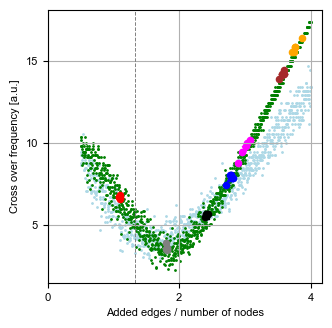

In [82]:
fig1=plt.figure(figsize=(9/2.54,9/2.54))
#fig1=plt.figure(figsize=(9/2.54 *0.4,3.5/2.54 *0.4))
#fig1=plt.figure(figsize=(3.5/2.54 ,3.5/2.54 ))
#fig1=plt.figure(figsize=(9/2.54 ,3.5/2.54 ))

ax1 = fig1.add_subplot(111)
#for i in range(len(loss_factors_list)):

#ax1.errorbar(rd_elem,len_f_range_list/(f_intersection_list),fmt=".")
#ax1.errorbar(rd_elem,f_intersection_list/f_max_loss_mod_list,fmt=".")

#ax1.errorbar(rd_elem,f_max_loss_mod_list,fmt=".",label="max loss mod")
x_scale_1=100/2
ax1.scatter(rd_elem/x_scale_1,f_intersection_list,label="Max. degree=99",alpha=1, color="lightblue",s=1)

ax1.scatter(rd_elem2/x_scale_1,f_intersection_list2,label="Max. degree=4",alpha=1, color="green",s=1)


colors_l=["red","grey","black","blue","magenta","brown","orange","pink","purple","yellow"]
marker_types=["+", "o", "s", "^", "v", "D", "*","x","p","+"]

for i in range(len(cross_links_all_sims_all)):
    ax1.scatter(np.array(cross_links_all_sims_all[i])/x_scale_1,f_intersection_ex_indv[i],label="Indv. sims",alpha=1,s=20,color=colors_l[i])

#ax1.hlines(f_intersection_2_exp_rs,25/x_scale_1,250/x_scale_1 ,linewidth=0.7,linestyle=":")
#ax1.errorbar(rd_elem_t1,f_intersection_t1,fmt="x", color="blue")

for i in range(len(mean_cross_links_all_sims_all)):
    ax1.scatter(mean_cross_links_all_sims_all[i]/x_scale_1,f_intersection_ex_all[i],s=20,marker=marker_types[i],color=colors_l[i],label="Simulation "+str(i+1) )
    
#ax1.errorbar(mean_cross_links_all_sims_ex1,f_intersection_ex1,fmt=".")
#ax1.errorbar(mean_cross_links_all_sims_ex2,f_intersection_ex2,fmt=".")
#ax1.errorbar(mean_cross_links_all_sims_ex3,f_intersection_ex3,fmt=".")
#ax1.errorbar(mean_cross_links_all_sims_ex4,f_intersection_ex4,fmt=".")


plt.axvline(1/3 *200 /x_scale_1,color="grey",linestyle="--",linewidth=0.7)
#plt.xlim(0,200)
#plt.ylim(0,20)

fs1=8
#plt.xscale("log")
#plt.yscale("log")
plt.grid()
'''plt.xlim(0,4)
plt.ylim(0,20)
plt.xticks([0,2,4],fontname = "Arial",fontsize=fs1)
plt.yticks([0,10,20],fontname = "Arial",fontsize=fs1)'''
plt.xticks([0,2,4],fontname = "Arial",fontsize=fs1)
plt.yticks([5,10,15],fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Cross over frequency [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_xlabel("Added edges / number of nodes",fontname = "Arial",fontsize=fs1)
#ax1.legend(loc="upper left",prop={'family': 'Arial','size': fs1})


save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/cross_over_freq_added_edges_2.pdf"

#plt.savefig(save_name_1,format="pdf",bbox_inches="tight")

Fitted parameters: a=0.9000194569917905,b=1.3810472145076644
R-squared: 0.960999324965409
RMSE: 0.533086329946258
R-squared, y=x+1: 0.9489530831390195
RMSE, y=x+1: 0.9537011695321469
R-squared, y=x+1, max. nodes=4: 0.9865001946514798
RMSE, y=x+1, max. nodes=4: 1.2163879303976683


/home/aaron/miniconda3/envs/bayesian_opt_1/lib/python3.9/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/aaron/miniconda3/envs/bayesian_opt_1/lib/python3.9/site-packages/matplotlib/collections.py:197: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


Text(0, 0.5, 'Crossover frequency [a.u.]')

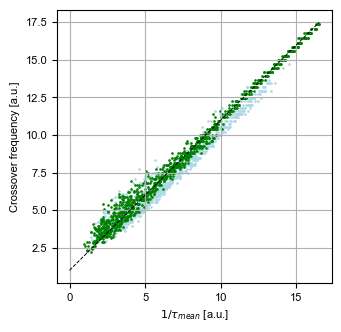

In [84]:
fig1=plt.figure(figsize=(9/2.54,9/2.54))
ax1 = fig1.add_subplot(111)

#colors_l=["red","black","darkblue","blue","magenta","brown","orange"]
#for i in range(len(relax_times_list[::20])):
#    num_modes_1=np.arange(0,len(relax_times_list[::20][i]))
#    ax1.scatter(num_modes_1,relax_times_list[::20][i],s=10,marker="^",label=i)


'''for i in range(len(relax_times_list[::])):
    #num_modes_1=np.arange(0,len(relax_times_list[::][i]))
    ax1.scatter(rd_elem[i]/x_scale_1,1/np.mean(relax_times_list[::][i]),s=1,marker="p",label=i,color="lightblue")

for i in range(len(relax_times_list[::])):
    #num_modes_1=np.arange(0,len(relax_times_list[::][i]))
    ax1.scatter(rd_elem2[i]/x_scale_1,1/np.mean(relax_times_list2[::][i]),s=1,marker="p",label=i,color="green")
'''
relax_times_list2_mean=np.array([np.mean(relax_times_list2[e]) for e in range(len(relax_times_list2))])
relax_times_list_mean=np.array([np.mean(relax_times_list[e]) for e in range(len(relax_times_list))])

inv_relax_times_list2_mean=np.array([np.mean(1/relax_times_list2[e]) for e in range(len(relax_times_list2))])
inv_relax_times_list_mean=np.array([np.mean(1/relax_times_list[e]) for e in range(len(relax_times_list))])

#ax1.scatter(rd_elem/x_scale_1,1/relax_times_list_mean,s=1,marker="p",label=i,color="lightblue")
#ax1.scatter(rd_elem2/x_scale_1,1/relax_times_list2_mean,s=1,marker="p",label=i,color="green")


def model3(x, a, b):
    return a * x +b



# Fit the curve

x1_t=1/relax_times_list_mean
x1=np.array([x.real if isinstance(x, complex) else x for x in x1_t])

y1_t=f_intersection_list
y1=np.array([x.real if isinstance(x, complex) else x for x in y1_t])

#max nodes =4

x2_t=1/relax_times_list2_mean
x2=np.array([x.real if isinstance(x, complex) else x for x in x2_t])

y2_t=f_intersection_list2
y2=np.array([x.real if isinstance(x, complex) else x for x in y2_t])
#y1=y1_t[np.isreal(y1_t)]

params, _ = curve_fit(model3, x1,y1,p0=[1,0])

# Extract fitted parameters
a, b = params
print(f"Fitted parameters: a={a},b={b}")

#plt.errorbar(x1,model3(x1,*params),color="grey",fmt="--")

#plt.errorbar(rd_elem,19000*rd_elem**-0.66 )

# Predict y values using the fitted model
y_pred = model3(x1, *params)

# Calculate goodness-of-fit quantifiers
r_squared = r2_score(y1, y_pred)
rmse = np.sqrt(mean_squared_error(y1, y_pred))

print(f"R-squared: {r_squared}")
print(f"RMSE: {rmse}")


# Calculate goodness-of-fit quantifiers
r_squared2 = r2_score(x1, y1-1)
rmse2 = np.sqrt(mean_squared_error(x1,y1))

print(f"R-squared, y=x+1: {r_squared2}")
print(f"RMSE, y=x+1: {rmse2}")


# Calculate goodness-of-fit quantifiers
r_squared3 = r2_score(x2, y2-1)
rmse3 = np.sqrt(mean_squared_error(x2,y2))

print(f"R-squared, y=x+1, max. nodes=4: {r_squared3}")
print(f"RMSE, y=x+1, max. nodes=4: {rmse3}")

lin_1=np.linspace(0,np.max([np.max(x1),np.max(x2)]))

plt.errorbar(lin_1,lin_1+1,color="black",fmt="--",linewidth=0.7)


ax1.scatter(1/relax_times_list_mean,f_intersection_list,s=1,marker="p",label=i,color="lightblue")
ax1.scatter(1/relax_times_list2_mean,f_intersection_list2,s=1,marker="p",label=i,color="green")


#ax1.scatter(inv_relax_times_list_mean,f_intersection_list,s=1,marker="p",label=i,color="lightblue")
#ax1.scatter(inv_relax_times_list2_mean,f_intersection_list2,s=1,marker="p",label=i,color="green")



fs1=8
#plt.xscale("log")
#plt.yscale("log")
plt.grid()
plt.xticks(fontname = "Arial",fontsize=fs1)
plt.yticks(fontname = "Arial",fontsize=fs1)
ax1.set_xlabel(r"$1/\tau_{mean}$ [a.u.]",fontname = "Arial",fontsize=fs1)
ax1.set_ylabel("Crossover frequency [a.u.]",fontname = "Arial",fontsize=fs1)
#ax1.legend(loc="upper left",prop={'family': 'Arial','size': fs1})

0 25.0


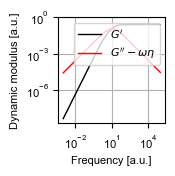

1 42.51751751751752


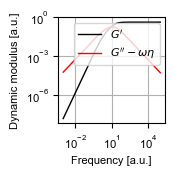

2 60.03503503503504


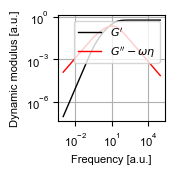

3 77.55255255255256


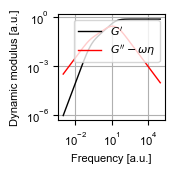

4 95.07007007007007


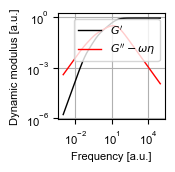

5 112.58758758758758


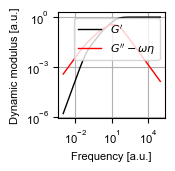

6 130.1051051051051


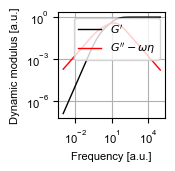

7 147.6226226226226


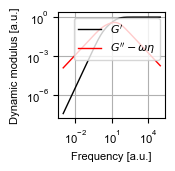

8 165.14014014014015


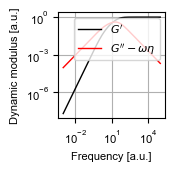

9 182.65765765765767


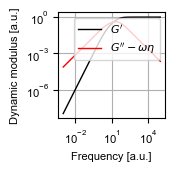

In [88]:

#for i in range(len(loss_factors_list)):
start1=0
step1=100
stop1=-1
for i in range(len(storage_mod_list2[start1:stop1:step1])):
    print(i,rd_elem2[start1:stop1:step1][i])
    fig1=plt.figure(figsize=(3.5/2.54,3.5/2.54))
    ax1 = fig1.add_subplot(111)
    
    ax1.errorbar(omega_t_len_s,storage_mod_list2[start1:stop1:step1][i],fmt="-",label=r"$G'$",color="black",linewidth=1)
    ax1.errorbar(omega_t_len_s,loss_mod_list2[start1:stop1:step1][i],fmt="-",label=r"$G''-\omega \eta$",color="red",linewidth=1)
    
    #ax1.errorbar(omega_t_len_s2,storage_mod_list2[1],fmt="-",color="black",linewidth=1)
    #ax1.errorbar(omega_t_len_s2,loss_mod_list2[1],fmt="-",color="red",linewidth=1)
    
    
    fs1=8
    plt.xscale("log")
    plt.yscale("log")
    plt.grid()
    plt.xticks([10**-2,10**1,10**4],fontname = "Arial",fontsize=fs1)
    plt.yticks([10**-6,10**-3,10**0],fontname = "Arial",fontsize=fs1)
    ax1.set_ylabel("Dynamic modulus [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.set_xlabel("Frequency [a.u.]",fontname = "Arial",fontsize=fs1)
    ax1.legend(loc="upper right",prop={'family': 'Arial','size': fs1})
    if i ==59:
        save_name_1="ML_parameter_opt_1/NCG_X_motif_conrad_1/figures/moduli_from_rd_graphs_120_edges_1.pdf"

        #plt.savefig(save_name_1,format="pdf",bbox_inches="tight")
     
    plt.show()